# 8. Lasso Augmented Reality Virtual Try-on Survey Data Analysis

In [17]:
import datetime

# Get the current date and time
now = datetime.datetime.now()

# Print the current date and time
print("Current date and time:", now)

Current date and time: 2024-10-30 10:47:31.573917


### Change Log

In [18]:
import pandas as pd
import numpy as np
from numpy import arange
import scipy.stats as stats
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score
# Load libraries
import numpy
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import semopy
from semopy import Model, Optimizer, calc_stats
#from pdpbox import pdp, get_dataset, info_plots
from sklearn.metrics import mutual_info_score
from sklearn import metrics
#import eli5
#from eli5.sklearn import PermutationImportance

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mutual_info_score
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint
 
# Models
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.cluster import KMeans

# Feature Selection and Dimensionality Reduction
from sklearn.decomposition import PCA
#from eli5.sklearn import PermutationImportance

# Statistical Analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from factor_analyzer import FactorAnalyzer
import semopy
from semopy import Model, Optimizer, calc_stats

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from pandas.plotting import scatter_matrix

#Model Interpretation
#import eli5

# Language Translation
from googletrans import Translator
translator = Translator()
from translate import Translator

translator = Translator(to_lang="en", from_lang="vi")
translation_1 = translator.translate("nữ")
translation_0 = translator.translate("nam")

print(f"Translation of 'nữ': {translation_1}")
print(f"Translation of 'nam': {translation_0}")

# Miscellaneous
# Set display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

Translation of 'nữ': female
Translation of 'nam': male


### Data Acquisition

In [19]:
#read csv file
df_survey_cleaned = pd.read_csv('df_survey_cleaned.csv')

In [20]:
#display column headers and the first row

df_survey_cleaned.head(2)

,Timestamp,AR_Knowledgeable,familiar_with_technology,use_AR_everyday,use_in_all_aspects,Virtual_shopping_environment,Virtual_tour,Visualize_model,Emulation,PE1,PE2,PE3,PE4,SOI1,SOI2,SOI3,SOI4,SEI1,SEI2,SEI3,PEOU1,PEOU2,PEOU3,PU1,PU2,PU3,PU4,B1,AT1,AT2,AT3,PPV1,PPV2,PPV3,HM1,HM2,HM3,BI1,BI2,BI3,BI4,Gender,AGE,Location,Gender_eng,Gender_vietnamese,Gender_num,AGE_eng,AGE_num,Age_vietnamese,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7,Usage_1_en,Usage_2_en,Usage_3_en,Usage_4_en,Usage_5_en,Usage_6_en,Usage_7_en,use_type_cnts,BI,PE,SOI,SEI,HM,AT,PPV,PU,PEOU,PE_centered,SOI_centered,SEI_centered,HM_centered,AT_centered,PPV_centered,PU_centered,PEOU_centered,AR_Knowledgeable_centered,familiar_with_technology_centered,use_AR_everyday_centered,Virtual_shopping_environment_centered,Virtual_tour_centered,Visualize_model_centered,Emulation_centered,AGEGender_centered,AGEAR_Knowledgeable,AGEfamiliar_with_technology,AGEuse_AR_everyday,AGEVirtual_shopping_environment,AGEVirtual_tour,AGEVisualize_model,AGEEmulation,GenderAR_Knowledgeable,Genderfamiliar_with_technology,Genderuse_AR_everyday,GenderVirtual_shopping_environment,GenderVirtual_tour,GenderVisualize_model,GenderEmulation,GenderPU_centered,GenderPE_centered,GenderPEOU_centered,GenderAT_centered,GenderPPV_centered,GenderHM_centered,GenderSOI_centered,GenderSEI_centered,AGEPEOU_centered,AGEPU_centered,AGESOI_centered,AGESEI_centered,AGEPPV_centered,AGEHM_centered,AGEPE_centered,AGEAT_centered,PEAT_centered,HMAT_centered,HMPU_centered,HMPEOU_centered,HMSOI_centered,HMSEI_centered,HMPE_centered,HMPPV_centered,SOIPU_centered,SEIPU_centered,SOIPEOU_centered,SEIPEOU_centered,target_variable_num,target_variable_cat,PE_centered_squared,PE_centered_cubed,SOI_centered_squared,SOI_centered_cubed,SEI_centered_squared,SEI_centered_cubed,HM_centered_squared,HM_centered_cubed,AT_centered_squared,AT_centered_cubed,PPV_centered_squared,PPV_centered_cubed,PU_centered_squared,PU_centered_cubed,PEOU_centered_squared,PEOU_centered_cubed,AGEGender_centered_squared,AGEGender_centered_cubed,GenderPU_centered_squared,GenderPU_centered_cubed,GenderPEOU_centered_squared,GenderPEOU_centered_cubed,GenderAT_centered_squared,GenderAT_centered_cubed,GenderPPV_centered_squared,GenderPPV_centered_cubed,GenderPE_centered_squared,GenderPE_centered_cubed,GenderHM_centered_squared,GenderHM_centered_cubed,GenderSOI_centered_squared,GenderSOI_centered_cubed,GenderSEI_centered_squared,GenderSEI_centered_cubed,AGEPEOU_centered_squared,AGEPEOU_centered_cubed,AGEPU_centered_squared,AGEPU_centered_cubed,AGESOI_centered_squared,AGESOI_centered_cubed,AGESEI_centered_squared,AGESEI_centered_cubed,AGEPPV_centered_squared,AGEPPV_centered_cubed,AGEHM_centered_squared,AGEHM_centered_cubed,AGEPE_centered_squared,AGEPE_centered_cubed,AGEAT_centered_squared,AGEAT_centered_cubed,PEAT_centered_squared,PEAT_centered_cubed,HMAT_centered_squared,HMAT_centered_cubed,HMPU_centered_squared,HMPU_centered_cubed,HMPEOU_centered_squared,HMPEOU_centered_cubed,HMSOI_centered_squared,HMSOI_centered_cubed,HMSEI_centered_squared,HMSEI_centered_cubed,HMPE_centered_squared,HMPE_centered_cubed
0,13/10/2022 11:08:13,4.0,3.0,3.0,Du lịch ảo / trải nghiệm,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,4.0,4.0,4.0,nam,Trên 40 tuổi,miền Bắc,male,nam,0,Over 40 years old,3,Trên 40 tuổi,Du lịch ảo,trải nghiệm,NaN,NaN,NaN,NaN,NaN,Du lịch ảo,experience,NaN,NaN,NaN,NaN,NaN,2,3.75,4.0,3.0,3.0,4.0,3.666667,4.0,3.25,4.0,0.205189,-0.714033,-0.72327,0.130503,-0.166667,0.211478,-0.568396,0.304245,1.025943,0.016509,0.325472,0.134434,0.233491,0.108491,0.228774,0,3.077830,0.049528,0.976415,0.403302,0.700472,0.325472,0.686321,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.00000,0.912736,-1.705189,-2.142099,-2.169811,0.634434,0.391509,0.615566,-0.500000,-0.034198,-0.021751,-0.074177,0.039705,-0.093184,-0.

In [21]:
#Get Size of dataset
df_survey_cleaned.shape



(424, 198)

In [22]:
df_survey_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Columns: 198 entries, Timestamp to HMPE_centered_cubed
dtypes: float64(168), int64(7), object(23)
memory usage: 656.0+ KB


# 1. Lasso Model using Original TAM Constructs, Gender, and Age as features.

Average MSE: 0.16670596384587705
Average R2: 0.7735567442237569
Lasso Regressor (Best Model) Results (5-fold Cross-Validation):
--------------------------------
Training MSE: 0.1484 (+/- 0.0295)
Training R^2: 0.8084 (+/- 0.0377)
Testing MSE: 0.1673 (+/- 0.1249)
Testing R^2: 0.7780 (+/- 0.1974)

Feature analysis results saved to: lasso_1_feature_analysis_results.json

LASSO 1 Feature Importance, MUI Scores, and PDP Ranges:
  model_name     feature  importance  mui_score  pdp_range
3      Lasso          HM    0.386904   0.710627   1.721247
4      Lasso          AT    0.116671   0.612903   0.539064
5      Lasso         PPV    0.083792   0.631970   0.409229
0      Lasso          PE    0.079385   0.511533   0.321050
7      Lasso     AGE_num    0.063507   0.546428   0.000000
1      Lasso         SOI    0.061572   0.546729   0.304998
6      Lasso          PU    0.046945   0.642224   0.230356
2      Lasso         SEI    0.019861   0.588142   0.031830
8      Lasso  Gender_num    0.001450   0.02

<Figure size 1500x1000 with 0 Axes>

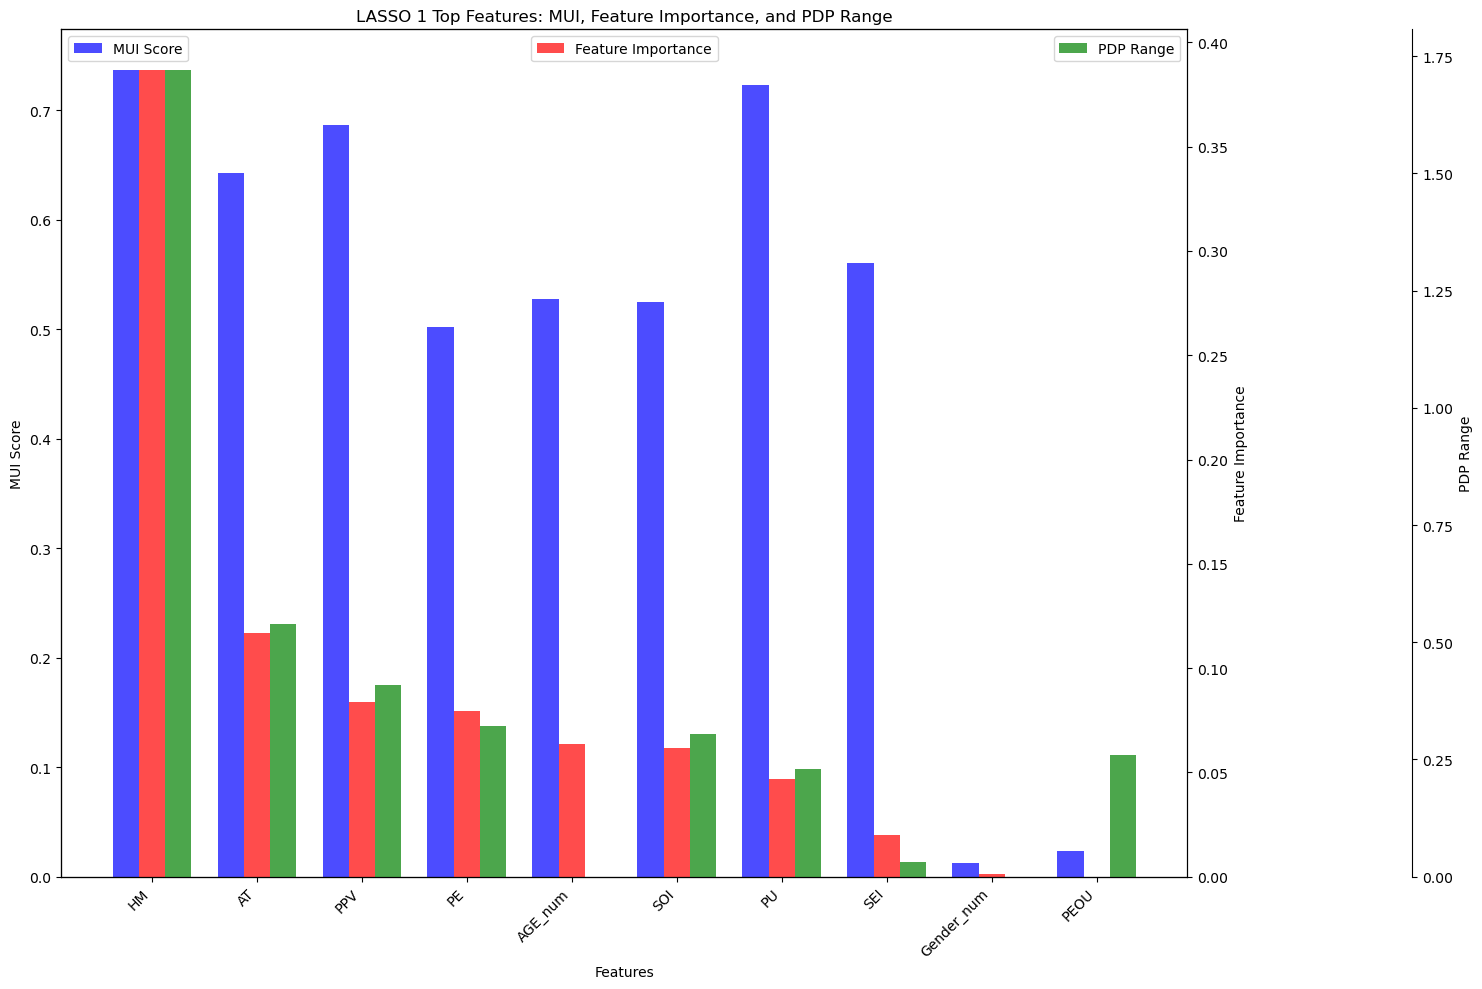

LASSO 1 Combined plot of MUI, Feature Importance, and PDP Range has been saved.
LASSO 1Combined top 15 features: ['HM', 'PU', 'PPV', 'AT', 'SEI', 'AGE_num', 'SOI', 'PE', 'PEOU', 'Gender_num']
Successfully saved top 15 features to C:\Users\cemcd\Documents\AR VTO Dissertation\AR VTO Dissertation Oct 6\AR VTO Latest Version Oct16 using PCA as Input\lasso_1_top_15_combined_features.json
Verified: Loaded 10 features from the file.
First few features: ['HM', 'PU', 'PPV', 'AT', 'SEI']

Top 15 combined feature names saved to: lasso_1_top_15_combined_features.json

Top 15 important feature names saved to: lasso_1_top_15_features.json
Updated feature importance DataFrame (including MUI scores) saved to: lasso_top_15_feature_names.csv
End of Script 1


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.linear_model import Lasso
from sklearn.inspection import partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
import json

# Assuming df_survey_cleaned is already defined
feature_vars = [
  'PE', 'SOI', 'SEI', 'HM', 'AT', 'PPV', 'PU', 'AGE_num','Gender_num','PEOU',
]

X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numeric and categorical features
numeric_features = [col for col in feature_vars if col not in ['AGE_num', 'Gender_num']]
categorical_features = ['AGE_num', 'Gender_num']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Perform cross-validation with MUI and feature importance
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
feature_importance = {feature: [] for feature in feature_vars}
mui_scores = {feature: [] for feature in feature_vars}

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Preprocess the data
    preprocessor.fit(X_fold_train)
    X_fold_train_preprocessed = preprocessor.transform(X_fold_train)
    X_fold_val_preprocessed = preprocessor.transform(X_fold_val)
    
    # Calculate MUI scores
    mui_fold_scores = mutual_info_regression(X_fold_train_preprocessed, y_fold_train)
    for i, feature in enumerate(feature_vars):
        mui_scores[feature].append(mui_fold_scores[i])
    
    # Train the model
    model = Lasso(alpha=.01, random_state=42)
    model.fit(X_fold_train_preprocessed, y_fold_train)
    
    # Calculate feature importance
    for i, feature in enumerate(feature_vars):
        feature_importance[feature].append(abs(model.coef_[i]))
    
    # Make predictions and calculate scores
    y_pred = model.predict(X_fold_val_preprocessed)
    mse = mean_squared_error(y_fold_val, y_pred)
    r2 = r2_score(y_fold_val, y_pred)
    
    cv_scores.append({'MSE': mse, 'R2': r2})

# Calculate average scores
avg_mse = np.mean([score['MSE'] for score in cv_scores])
avg_r2 = np.mean([score['R2'] for score in cv_scores])

print(f"Average MSE: {avg_mse}")
print(f"Average R2: {avg_r2}")

# Perform cross-validation on the best model
cv_results = cross_validate(model, X_train, y_train, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)

# Calculate mean and std of the scores
train_mse = -cv_results['train_neg_mean_squared_error']
test_mse = -cv_results['test_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_r2 = cv_results['test_r2']

print("Lasso Regressor (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['LASSO 1 (TAM )'],
    'run_type': ['Initial Run'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]
})

#save model metrics to csv 
model_metrics.to_csv('lasso_1_model_metrics.csv',index=False)

# Calculate average feature importance and MUI scores
avg_feature_importance = {feature: np.mean(scores) for feature, scores in feature_importance.items()}
avg_mui_scores = {feature: np.mean(scores) for feature, scores in mui_scores.items()}

# Sort features by importance
sorted_features = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)
top_features = [feature for feature, _ in sorted_features[:15]]

# Fit the final model on the entire training set
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=.01, random_state=42))
])
pipeline.fit(X_train, y_train)

# Calculate PDP values for top features
pdp_values = {}
pdp_ranges = {}

for feature in top_features:
    pdp = partial_dependence(pipeline, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp["values"][0], pdp["average"][0])
    pdp_ranges[feature] = np.ptp(pdp["average"][0])  # Range of PDP values

# Create results dictionary
results = {
    'top_features': top_features,
    'feature_importance': {feature: avg_feature_importance[feature] for feature in top_features},
    'mui_scores': {feature: avg_mui_scores[feature] for feature in top_features},
    'pdp_values': {feature: pdp_values[feature][1].tolist() for feature in top_features},
    'pdp_feature_values': {feature: pdp_values[feature][0].tolist() for feature in top_features}
}

# Save results to JSON file
with open('lasso_1_feature_analysis_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nFeature analysis results saved to: lasso_1_feature_analysis_results.json")

# Create lasso_important_features dataframe
important_features = pd.DataFrame([
    {'feature': feature, 'importance': avg_feature_importance[feature], 
     'mui_score': avg_mui_scores[feature], 'pdp_range': pdp_ranges.get(feature, np.nan)}
    for feature in feature_vars
])
lasso_1_important_features = important_features.sort_values('importance', ascending=False)
lasso_1_important_features.insert(0, 'model_name', 'Lasso')

print("\nLASSO 1 Feature Importance, MUI Scores, and PDP Ranges:")
print(lasso_1_important_features)

# Save dataframe to CSV file
lasso_1_important_features.to_csv('lasso_1_important_features.csv', index=False)
print("\nLASSO 1 Feature importance dataframe saved to: lasso_1_important_features.csv")

# Evaluate the model on the training set
y_train_pred = pipeline.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("\nTraining set evaluation:")
print(f"Training set MSE: {train_mse:.4f}")
print(f"Training set R2: {train_r2:.4f}")

# Evaluate the model on the test set
y_test_pred = pipeline.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("\nTest set evaluation:")
print(f"Test set MSE: {test_mse:.4f}")
print(f"Test set R2: {test_r2:.4f}")

# Calculate and print the difference between training and test performance
mse_difference = train_mse - test_mse
r2_difference = train_r2 - test_r2
print("\nDifference between training and test performance:")
print(f"MSE difference (train - test): {mse_difference:.4f}")
print(f"R2 difference (train - test): {r2_difference:.4f}")


# After calculating PDP values and ranges, add this code:

# Calculate MUI scores for the entire training set
X_train_preprocessed = preprocessor.fit_transform(X_train)
mui_scores = mutual_info_regression(X_train_preprocessed, y_train)
mui_dict = dict(zip(feature_vars, mui_scores))

# Create a combined bar plot for MUI, Feature Importance, and PDP Range
plt.figure(figsize=(15, 10))
x = range(len(top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the right spine of ax3 by 60 points
ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [mui_dict[f] for f in top_features], width, label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [avg_feature_importance[f] for f in top_features], width, label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges[f] for f in top_features], width, label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('LASSO 1 Top Features: MUI, Feature Importance, and PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(top_features, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

fig.tight_layout()
plt.show()
plt.savefig('lasso_1_top_features_mui_importance_pdp.png', dpi=300, bbox_inches='tight')
plt.close()

print("LASSO 1 Combined plot of MUI, Feature Importance, and PDP Range has been saved.")

# Update the results dictionary to include MUI scores
results['mui_scores'] = {feature: mui_dict[feature] for feature in top_features}

# Get top 15 features based on MUI scores
mui_top_15 = sorted(mui_dict.items(), key=lambda x: x[1], reverse=True)[:15]
mui_top_15_names = [feature for feature, _ in mui_top_15]

# Get top 15 features based on PDP ranges
pdp_top_15 = sorted(pdp_ranges.items(), key=lambda x: x[1], reverse=True)[:15]
pdp_top_15_names = [feature for feature, _ in pdp_top_15]

# Get top 15 features based on feature importance
importance_top_15 = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)[:15]
importance_top_15_names = [feature for feature, _ in importance_top_15]

# Combine all top features and remove duplicates while preserving order
all_top_features = mui_top_15_names + pdp_top_15_names + importance_top_15_names
lasso_top_15_feature_names = list(dict.fromkeys(all_top_features))[:15]

print(f"LASSO 1Combined top 15 features: {lasso_top_15_feature_names}")

import os
import json

# Define the file name
file_name = 'lasso_1_top_15_combined_features.json'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
results_file_path = os.path.join(current_dir, file_name)

try:
    # Save the top 15 important features to a JSON file
    with open(results_file_path, 'w') as f:
        json.dump(lasso_top_15_feature_names, f, indent=4)
    print(f"Successfully saved top 15 features to {results_file_path}")
    
    # Verify the saved data
    with open(results_file_path, 'r') as f:
        loaded_features = json.load(f)
    print(f"Verified: Loaded {len(loaded_features)} features from the file.")
    print("First few features:", loaded_features[:5])
except Exception as e:
    print(f"An error occurred: {str(e)}")

print("\nTop 15 combined feature names saved to: lasso_1_top_15_combined_features.json")

print("\nTop 15 important feature names saved to: lasso_1_top_15_features.json")

# Update the lasso_important_features DataFrame to include MUI scores
lasso_1_important_features['mui_score'] = lasso_1_important_features['feature'].map(mui_dict)

# Save DataFrame to CSV
lasso_1_important_features.to_csv('lasso_top_15_feature_names.csv', index=False)
print("Updated feature importance DataFrame (including MUI scores) saved to: lasso_top_15_feature_names.csv")
print('End of Script 1')

## 2A. LASSO Model with default parameters using PCA List

2.A 
Type of pca_selected_features: <class 'list'>
First few items in pca_selected_features:
  AGEGender_centered_squared (type: <class 'str'>)
  AGEGender_centered (type: <class 'str'>)
  GenderPEOU_centered_squared (type: <class 'str'>)
  AGEPEOU_centered_squared (type: <class 'str'>)
  GenderPEOU_centered (type: <class 'str'>)

Successfully loaded 10 unique PCA selected features.

First 5 features:
- AGEGender_centered_squared
- AGEGender_centered
- GenderPEOU_centered_squared
- AGEPEOU_centered_squared
- GenderPEOU_centered

Last 5 features:
- HMSOI_centered
- PEAT_centered
- HMPE_centered
- AGE_num_1
- AGE_num_2

Number of unique features: 10
Number of features selected: 64
Selected features:
['AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared', 'GenderPEOU_centered', 'AGESOI_centered_squared', 'AGESEI_centered_squared', 'PEOU_centered_squared', 'AGEPEOU_centered', 'PEOU_centered', 'AGEPPV_centered_squared', 'GenderAT_cente

<Figure size 1500x1000 with 0 Axes>

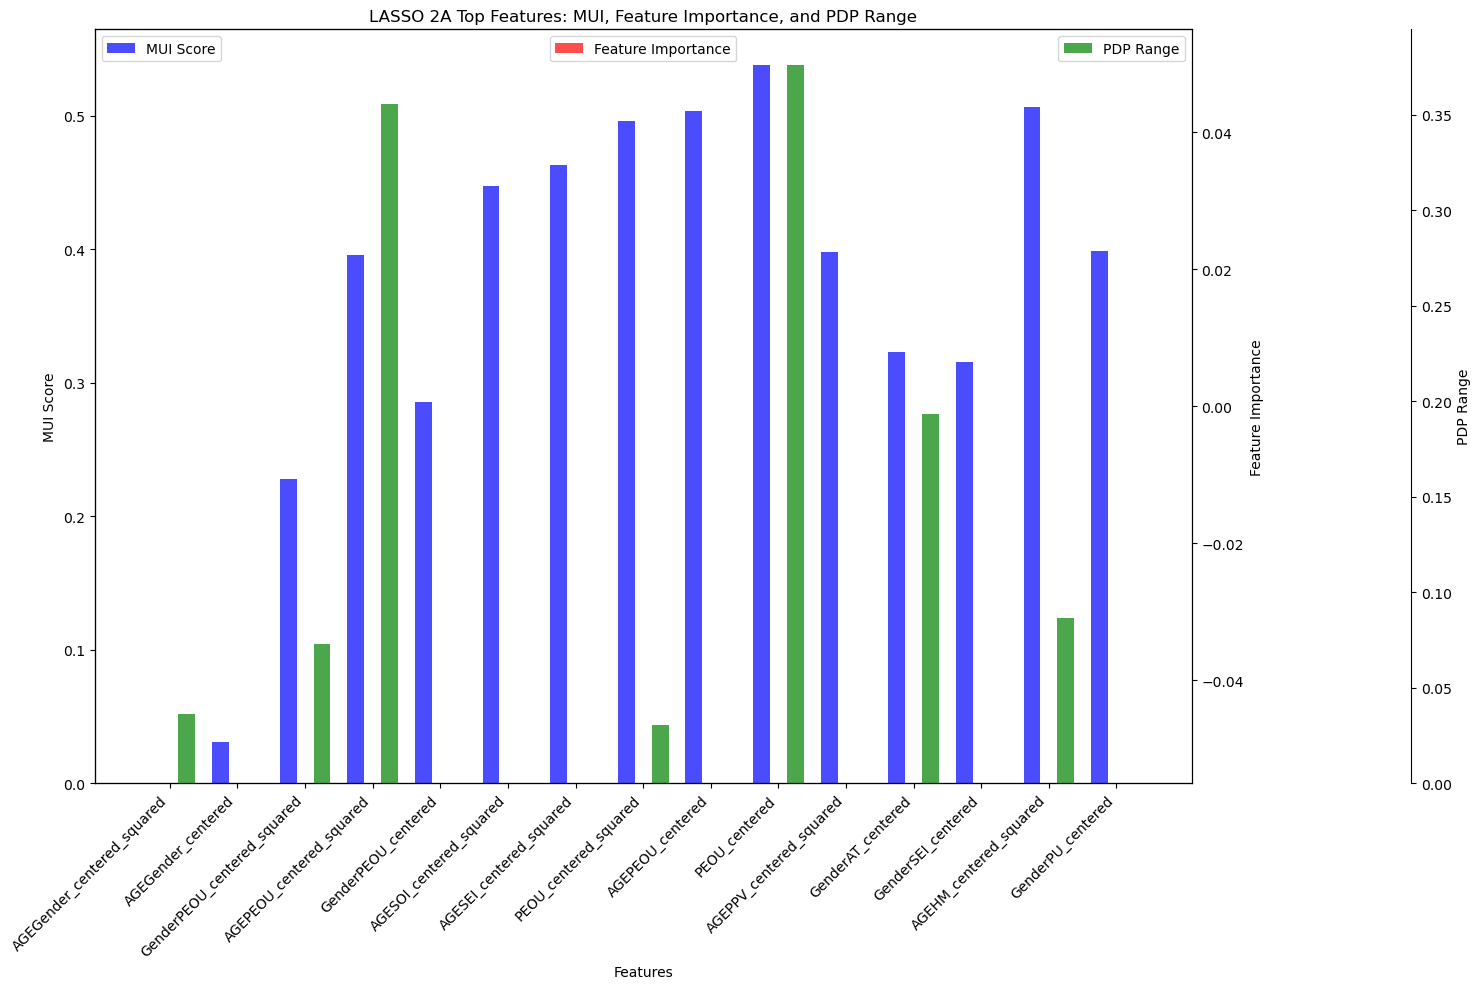

LASSO 2A Combined plot of MUI, Feature Importance, and PDP Range has been saved.
LASSO 2A Combined top 15 features: ['HMPU_centered', 'HMAT_centered_squared', 'HM_centered', 'HMPU_centered_squared', 'PU_centered', 'HMSEI_centered_squared', 'HM_centered_squared', 'PPV_centered', 'HMSEI_centered', 'PU_centered_squared', 'AGEHM_centered', 'HMPEOU_centered_squared', 'HMPEOU_centered', 'AGESOI_centered', 'HMPE_centered_squared']
Successfully saved top 15 features to C:\Users\cemcd\Documents\AR VTO Dissertation\AR VTO Dissertation Oct 6\AR VTO Latest Version Oct16 using PCA as Input\lasso_2A_top_15_combined_features.json
Verified: Loaded 15 features from the file.
First few features: ['HMPU_centered', 'HMAT_centered_squared', 'HM_centered', 'HMPU_centered_squared', 'PU_centered']

Top 15 combined feature names saved to: lasso_2A_top_15_combined_features.json

Top 15 important feature names saved to: lasso_2A_top_15_features.json
Updated feature importance DataFrame (including MUI scores) sav

In [24]:
print('2.A ')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.linear_model import Lasso
from sklearn.inspection import partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
import json

# Assuming df_survey_cleaned is already defined
# Open and read the JSON file
try:
    with open('PCA_selected_features.json', 'r') as json_file:
        feature_data = json.load(json_file)

    # Extract the list of selected features
    pca_selected_features = feature_data['PCA_selected_features']

    print("Type of pca_selected_features:", type(pca_selected_features))
    print("First few items in pca_selected_features:")
    for item in pca_selected_features[:5]:
        print(f"  {item} (type: {type(item)})")

    # If pca_selected_features is a list of strings, use this:
    selected_features = list(dict.fromkeys(pca_selected_features))

    print(f"\nSuccessfully loaded {len(feature_vars)} unique PCA selected features.")
    print("\nFirst 5 features:")
    for feature in selected_features[:5]:
        print(f"- {feature}")

    print(f"\nLast 5 features:")
    for feature in selected_features[-5:]:
        print(f"- {feature}")

    print(f"\nNumber of unique features: {len(feature_vars)}")

except FileNotFoundError:
    print("Error: The file 'PCA_selected_features.json' was not found.")
except json.JSONDecodeError:
    print("Error: There was a problem decoding the JSON file.")
except KeyError:
    print("Error: The key 'PCA_selected_features' was not found in the JSON file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
# Select the first 30 features from feature_vars
#feature_vars = selected_features[:30]

feature_vars = selected_features

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

# AGE and Gender are both numerical categorical features, check to see if AGE_num_1, 2,3 and Gender_num_1 are in the PCA list but not in df_survey_cleaned
missing_columns = [col for col in feature_vars if col not in df_survey_cleaned.columns]
print("Missing columns:", missing_columns)

# First, check if 'AGE' and 'Gender' columns exist
if 'AGE_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            # Binary variable
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            # Categorical variable
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

# Convert boolean columns to int
bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

# Ensure all features are numeric
feature_vars = [col for col in feature_vars if df_survey_cleaned[col].dtype in ['int64', 'float64']]

print("Updated feature variables:", feature_vars)
print(df_survey_cleaned[feature_vars].dtypes)



X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numeric and categorical features
numeric_features = [col for col in feature_vars if col not in ['AGE_num', 'Gender_num']]
categorical_features = ['AGE_num', 'Gender_num']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
        #,('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Perform cross-validation with MUI and feature importance
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
feature_importance = {feature: [] for feature in feature_vars}
mui_scores = {feature: [] for feature in feature_vars}

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Preprocess the data
    preprocessor.fit(X_fold_train)
    X_fold_train_preprocessed = preprocessor.transform(X_fold_train)
    X_fold_val_preprocessed = preprocessor.transform(X_fold_val)
    
    # Calculate MUI scores
    mui_fold_scores = mutual_info_regression(X_fold_train_preprocessed, y_fold_train)
    for i, feature in enumerate(feature_vars):
        mui_scores[feature].append(mui_fold_scores[i])
    
    # Train the model
    #model = Lasso(alpha=.01, random_state=42)
    model = Lasso(random_state=42)
    model.fit(X_fold_train_preprocessed, y_fold_train)
    
    # Calculate feature importance
    for i, feature in enumerate(feature_vars):
        feature_importance[feature].append(abs(model.coef_[i]))
    
    # Make predictions and calculate scores
    y_pred = model.predict(X_fold_val_preprocessed)
    mse = mean_squared_error(y_fold_val, y_pred)
    r2 = r2_score(y_fold_val, y_pred)
    
    cv_scores.append({'MSE': mse, 'R2': r2})

# Calculate average scores
avg_mse = np.mean([score['MSE'] for score in cv_scores])
avg_r2 = np.mean([score['R2'] for score in cv_scores])

print(f"Average MSE: {avg_mse}")
print(f"Average R2: {avg_r2}")

# Perform cross-validation on the best model
cv_results = cross_validate(model, X_train, y_train, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)

# Calculate mean and std of the scores
train_mse = -cv_results['train_neg_mean_squared_error']
test_mse = -cv_results['test_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_r2 = cv_results['test_r2']

print("Lasso 2A Regressor (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['LASSO 2A (PCA)'],
    'run_type': ['2 Run Default Paramaters'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]
})

#save model metrics to csv 
model_metrics.to_csv('lasso_2A_model_metrics.csv',index=False)

# Calculate average feature importance and MUI scores
avg_feature_importance = {feature: np.mean(scores) for feature, scores in feature_importance.items()}
avg_mui_scores = {feature: np.mean(scores) for feature, scores in mui_scores.items()}

# Sort features by importance
sorted_features = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)
top_features = [feature for feature, _ in sorted_features[:15]]

# Fit the final model on the entire training set
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=.01, random_state=42))
])
pipeline.fit(X_train, y_train)

# Calculate PDP values for top features
pdp_values = {}
pdp_ranges = {}

for feature in top_features:
    pdp = partial_dependence(pipeline, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp["values"][0], pdp["average"][0])
    pdp_ranges[feature] = np.ptp(pdp["average"][0])  # Range of PDP values

# Create results dictionary
results = {
    'top_features': top_features,
    'feature_importance': {feature: avg_feature_importance[feature] for feature in top_features},
    'mui_scores': {feature: avg_mui_scores[feature] for feature in top_features},
    'pdp_values': {feature: pdp_values[feature][1].tolist() for feature in top_features},
    'pdp_feature_values': {feature: pdp_values[feature][0].tolist() for feature in top_features}
}

# Save results to JSON file
with open('lasso_2A_feature_analysis_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nFeature analysis results saved to: lasso_2A_feature_analysis_results.json")

# Create lasso_important_features dataframe
important_features = pd.DataFrame([
    {'feature': feature, 'importance': avg_feature_importance[feature], 
     'mui_score': avg_mui_scores[feature], 'pdp_range': pdp_ranges.get(feature, np.nan)}
    for feature in feature_vars
])
lasso_2A_important_features = important_features.sort_values('importance', ascending=False)
lasso_2A_important_features.insert(0, 'model_name', 'Lasso')

print("\nLASSO 2A Feature Importance, MUI Scores, and PDP Ranges:")
print(lasso_2A_important_features)

# Save dataframe to CSV file
lasso_2A_important_features.to_csv('lasso_2A_important_features.csv', index=False)
print("\nLASSO 2A Feature importance dataframe saved to: lasso_2A_important_features.csv")

# Evaluate the model on the training set
y_train_pred = pipeline.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("\nTraining set evaluation:")
print(f"Training set MSE: {train_mse:.4f}")
print(f"Training set R2: {train_r2:.4f}")

# Evaluate the model on the test set
y_test_pred = pipeline.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("\nTest set evaluation:")
print(f"Test set MSE: {test_mse:.4f}")
print(f"Test set R2: {test_r2:.4f}")

# Calculate and print the difference between training and test performance
mse_difference = train_mse - test_mse
r2_difference = train_r2 - test_r2
print("\nDifference between training and test performance:")
print(f"MSE difference (train - test): {mse_difference:.4f}")
print(f"R2 difference (train - test): {r2_difference:.4f}")


# After calculating PDP values and ranges, add this code:

# Calculate MUI scores for the entire training set
X_train_preprocessed = preprocessor.fit_transform(X_train)
mui_scores = mutual_info_regression(X_train_preprocessed, y_train)
mui_dict = dict(zip(feature_vars, mui_scores))

# Create a combined bar plot for MUI, Feature Importance, and PDP Range
plt.figure(figsize=(15, 10))
x = range(len(top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the right spine of ax3 by 60 points
ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [mui_dict[f] for f in top_features], width, label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [avg_feature_importance[f] for f in top_features], width, label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges[f] for f in top_features], width, label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('LASSO 2A Top Features: MUI, Feature Importance, and PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(top_features, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

fig.tight_layout()
plt.show()
plt.savefig('lasso_2A_top_features_mui_importance_pdp.png', dpi=300, bbox_inches='tight')
plt.close()

print("LASSO 2A Combined plot of MUI, Feature Importance, and PDP Range has been saved.")

# Update the results dictionary to include MUI scores
results['mui_scores'] = {feature: mui_dict[feature] for feature in top_features}

# Get top 15 features based on MUI scores
mui_top_15 = sorted(mui_dict.items(), key=lambda x: x[1], reverse=True)[:15]
mui_top_15_names = [feature for feature, _ in mui_top_15]

# Get top 15 features based on PDP ranges
pdp_top_15 = sorted(pdp_ranges.items(), key=lambda x: x[1], reverse=True)[:15]
pdp_top_15_names = [feature for feature, _ in pdp_top_15]

# Get top 15 features based on feature importance
importance_top_15 = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)[:15]
importance_top_15_names = [feature for feature, _ in importance_top_15]

# Combine all top features and remove duplicates while preserving order
all_top_features = mui_top_15_names + pdp_top_15_names + importance_top_15_names
lasso_top_15_feature_names = list(dict.fromkeys(all_top_features))[:15]

print(f"LASSO 2A Combined top 15 features: {lasso_top_15_feature_names}")

import os
import json

# Define the file name
file_name = 'lasso_2A_top_15_combined_features.json'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
results_file_path = os.path.join(current_dir, file_name)

try:
    # Save the top 15 important features to a JSON file
    with open(results_file_path, 'w') as f:
        json.dump(lasso_top_15_feature_names, f, indent=4)
    print(f"Successfully saved top 15 features to {results_file_path}")
    
    # Verify the saved data
    with open(results_file_path, 'r') as f:
        loaded_features = json.load(f)
    print(f"Verified: Loaded {len(loaded_features)} features from the file.")
    print("First few features:", loaded_features[:5])
except Exception as e:
    print(f"An error occurred: {str(e)}")

print("\nTop 15 combined feature names saved to: lasso_2A_top_15_combined_features.json")

print("\nTop 15 important feature names saved to: lasso_2A_top_15_features.json")

# Update the lasso_important_features DataFrame to include MUI scores
lasso_2A_important_features['mui_score'] = lasso_2A_important_features['feature'].map(mui_dict)

# Save DataFrame to CSV
lasso_2A_important_features.to_csv('lasso_2A_top_15_feature_names.csv', index=False)
print("Updated feature importance DataFrame (including MUI scores) saved to: lasso_2A_top_15_feature_names.csv")
print('End of Script 2A')

## 2 B. Lasso Model using PCA Feature List.

2.B 
Type of pca_selected_features: <class 'list'>
First few items in pca_selected_features:
  AGEGender_centered_squared (type: <class 'str'>)
  AGEGender_centered (type: <class 'str'>)
  GenderPEOU_centered_squared (type: <class 'str'>)
  AGEPEOU_centered_squared (type: <class 'str'>)
  GenderPEOU_centered (type: <class 'str'>)

Successfully loaded 60 unique PCA selected features.

First 5 features:
- AGEGender_centered_squared
- AGEGender_centered
- GenderPEOU_centered_squared
- AGEPEOU_centered_squared
- GenderPEOU_centered

Last 5 features:
- HMSOI_centered
- PEAT_centered
- HMPE_centered
- AGE_num_1
- AGE_num_2

Number of unique features: 60
Number of features selected: 64
Selected features:
['AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared', 'GenderPEOU_centered', 'AGESOI_centered_squared', 'AGESEI_centered_squared', 'PEOU_centered_squared', 'AGEPEOU_centered', 'PEOU_centered', 'AGEPPV_centered_squared', 'GenderAT_cente

<Figure size 1500x1000 with 0 Axes>

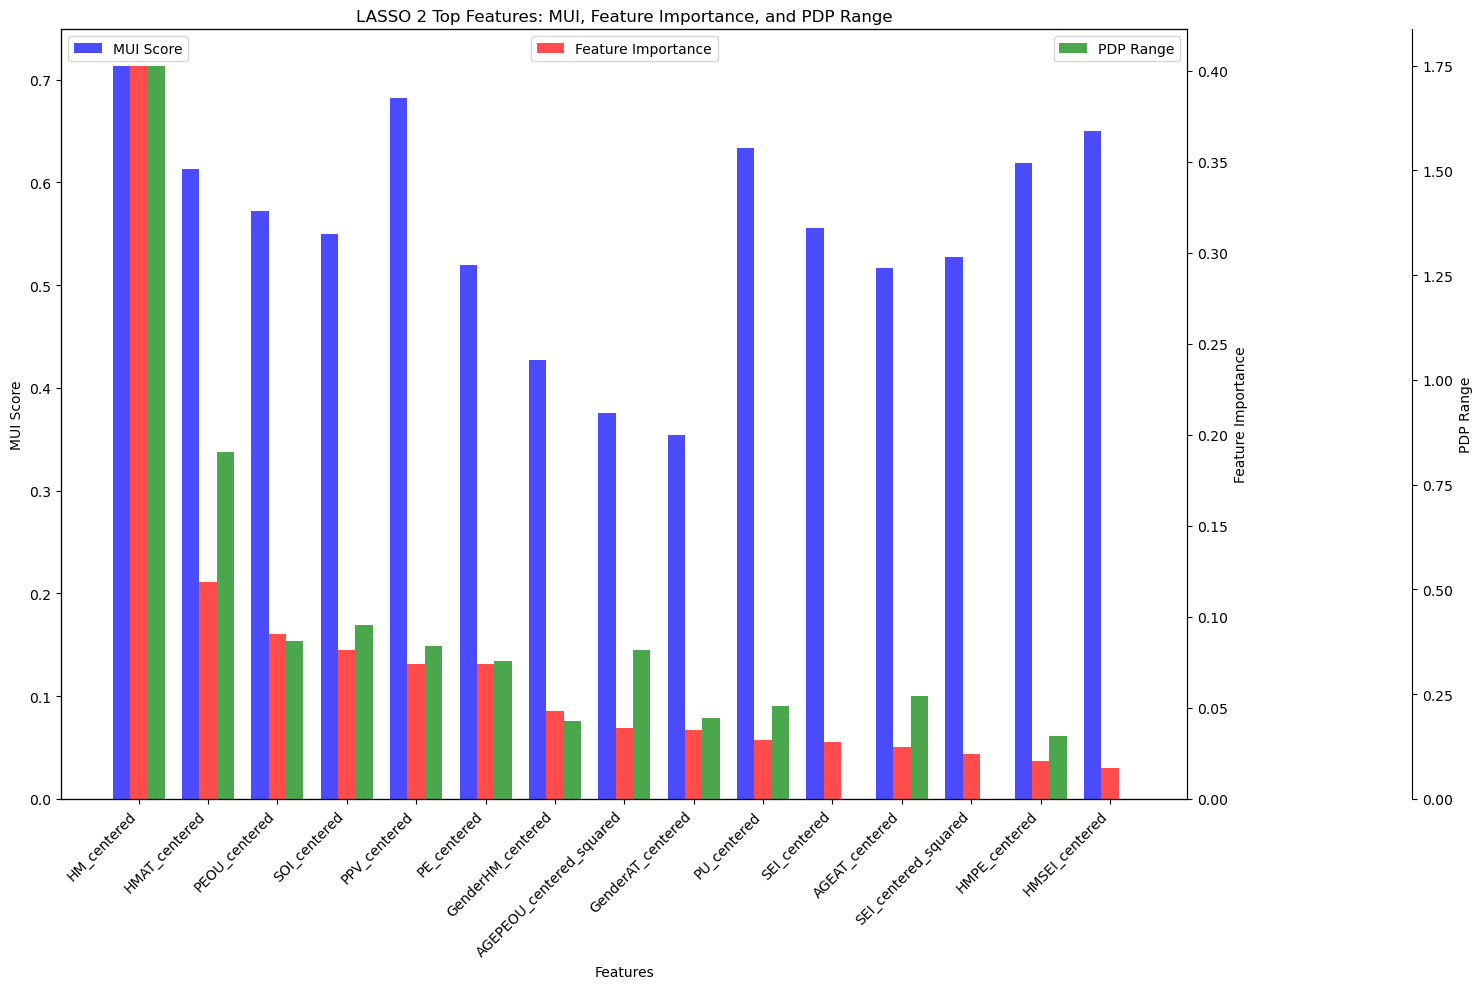

LASSO 2 Combined plot of MUI, Feature Importance, and PDP Range has been saved.
LASSO 2 Combined top 15 features: ['HMPU_centered', 'HM_centered', 'HMAT_centered_squared', 'PPV_centered', 'HM_centered_squared', 'HMPU_centered_squared', 'HMSEI_centered_squared', 'HMSEI_centered', 'HMPEOU_centered', 'PU_centered', 'HMPEOU_centered_squared', 'AGEHM_centered', 'PPV_centered_squared', 'HMPE_centered', 'HMAT_centered']
Successfully saved top 15 features to C:\Users\cemcd\Documents\AR VTO Dissertation\AR VTO Dissertation Oct 6\AR VTO Latest Version Oct16 using PCA as Input\lasso_2_top_15_combined_features.json
Verified: Loaded 15 features from the file.
First few features: ['HMPU_centered', 'HM_centered', 'HMAT_centered_squared', 'PPV_centered', 'HM_centered_squared']

Top 15 combined feature names saved to: lasso_2_top_15_combined_features.json

Top 15 important feature names saved to: lasso_2_top_15_features.json
Updated feature importance DataFrame (including MUI scores) saved to: lasso_to

In [25]:
print('2.B ')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.linear_model import Lasso
from sklearn.inspection import partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
import json

# Assuming df_survey_cleaned is already defined
# Open and read the JSON file
try:
    with open('PCA_selected_features.json', 'r') as json_file:
        feature_data = json.load(json_file)

    # Extract the list of selected features
    pca_selected_features = feature_data['PCA_selected_features']

    print("Type of pca_selected_features:", type(pca_selected_features))
    print("First few items in pca_selected_features:")
    for item in pca_selected_features[:5]:
        print(f"  {item} (type: {type(item)})")

    # If pca_selected_features is a list of strings, use this:
    selected_features = list(dict.fromkeys(pca_selected_features))

    print(f"\nSuccessfully loaded {len(feature_vars)} unique PCA selected features.")
    print("\nFirst 5 features:")
    for feature in selected_features[:5]:
        print(f"- {feature}")

    print(f"\nLast 5 features:")
    for feature in selected_features[-5:]:
        print(f"- {feature}")

    print(f"\nNumber of unique features: {len(feature_vars)}")

except FileNotFoundError:
    print("Error: The file 'PCA_selected_features.json' was not found.")
except json.JSONDecodeError:
    print("Error: There was a problem decoding the JSON file.")
except KeyError:
    print("Error: The key 'PCA_selected_features' was not found in the JSON file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
# Select the first 30 features from feature_vars
#feature_vars = selected_features[:30]

feature_vars = selected_features

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

# AGE and Gender are both numerical categorical features, check to see if AGE_num_1, 2,3 and Gender_num_1 are in the PCA list but not in df_survey_cleaned
missing_columns = [col for col in feature_vars if col not in df_survey_cleaned.columns]
print("Missing columns:", missing_columns)

# First, check if 'AGE' and 'Gender' columns exist
if 'AGE_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            # Binary variable
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            # Categorical variable
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

# Convert boolean columns to int
bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

# Ensure all features are numeric
feature_vars = [col for col in feature_vars if df_survey_cleaned[col].dtype in ['int64', 'float64']]

print("Updated feature variables:", feature_vars)
print(df_survey_cleaned[feature_vars].dtypes)



X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numeric and categorical features
numeric_features = [col for col in feature_vars if col not in ['AGE_num', 'Gender_num']]
categorical_features = ['AGE_num', 'Gender_num']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
        #,('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Perform cross-validation with MUI and feature importance
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
feature_importance = {feature: [] for feature in feature_vars}
mui_scores = {feature: [] for feature in feature_vars}

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Preprocess the data
    preprocessor.fit(X_fold_train)
    X_fold_train_preprocessed = preprocessor.transform(X_fold_train)
    X_fold_val_preprocessed = preprocessor.transform(X_fold_val)
    
    # Calculate MUI scores
    mui_fold_scores = mutual_info_regression(X_fold_train_preprocessed, y_fold_train)
    for i, feature in enumerate(feature_vars):
        mui_scores[feature].append(mui_fold_scores[i])
    
    # Train the model
    model = Lasso(alpha=.01, random_state=42)
    #model = Lasso(random_state=42)
    model.fit(X_fold_train_preprocessed, y_fold_train)
    
    # Calculate feature importance
    for i, feature in enumerate(feature_vars):
        feature_importance[feature].append(abs(model.coef_[i]))
    
    # Make predictions and calculate scores
    y_pred = model.predict(X_fold_val_preprocessed)
    mse = mean_squared_error(y_fold_val, y_pred)
    r2 = r2_score(y_fold_val, y_pred)
    
    cv_scores.append({'MSE': mse, 'R2': r2})

# Calculate average scores
avg_mse = np.mean([score['MSE'] for score in cv_scores])
avg_r2 = np.mean([score['R2'] for score in cv_scores])

print(f"Average MSE: {avg_mse}")
print(f"Average R2: {avg_r2}")

# Perform cross-validation on the best model
cv_results = cross_validate(model, X_train, y_train, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)

# Calculate mean and std of the scores
train_mse = -cv_results['train_neg_mean_squared_error']
test_mse = -cv_results['test_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_r2 = cv_results['test_r2']

print("Lasso 2 Regressor (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['LASSO 2A (PCA)'],
    'run_type': ['2 Run Alpha = 0.01'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]
})

#save model metrics to csv 
model_metrics.to_csv('lasso_2_model_metrics.csv',index=False)

# Calculate average feature importance and MUI scores
avg_feature_importance = {feature: np.mean(scores) for feature, scores in feature_importance.items()}
avg_mui_scores = {feature: np.mean(scores) for feature, scores in mui_scores.items()}

# Sort features by importance
sorted_features = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)
top_features = [feature for feature, _ in sorted_features[:15]]

# Fit the final model on the entire training set
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=.01, random_state=42))
])
pipeline.fit(X_train, y_train)

# Calculate PDP values for top features
pdp_values = {}
pdp_ranges = {}

for feature in top_features:
    pdp = partial_dependence(pipeline, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp["values"][0], pdp["average"][0])
    pdp_ranges[feature] = np.ptp(pdp["average"][0])  # Range of PDP values

# Create results dictionary
results = {
    'top_features': top_features,
    'feature_importance': {feature: avg_feature_importance[feature] for feature in top_features},
    'mui_scores': {feature: avg_mui_scores[feature] for feature in top_features},
    'pdp_values': {feature: pdp_values[feature][1].tolist() for feature in top_features},
    'pdp_feature_values': {feature: pdp_values[feature][0].tolist() for feature in top_features}
}

# Save results to JSON file
with open('lasso_2_feature_analysis_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nFeature analysis results saved to: lasso_2_feature_analysis_results.json")

# Create lasso_important_features dataframe
important_features = pd.DataFrame([
    {'feature': feature, 'importance': avg_feature_importance[feature], 
     'mui_score': avg_mui_scores[feature], 'pdp_range': pdp_ranges.get(feature, np.nan)}
    for feature in feature_vars
])
lasso_2_important_features = important_features.sort_values('importance', ascending=False)
lasso_2_important_features.insert(0, 'model_name', 'Lasso')

print("\nLASSO 2 Feature Importance, MUI Scores, and PDP Ranges:")
print(lasso_2_important_features)

# Save dataframe to CSV file
lasso_2_important_features.to_csv('lasso_2_important_features.csv', index=False)
print("\nLASSO 2 Feature importance dataframe saved to: lasso_2_important_features.csv")

# Evaluate the model on the training set
y_train_pred = pipeline.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("\nTraining set evaluation:")
print(f"Training set MSE: {train_mse:.4f}")
print(f"Training set R2: {train_r2:.4f}")

# Evaluate the model on the test set
y_test_pred = pipeline.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("\nTest set evaluation:")
print(f"Test set MSE: {test_mse:.4f}")
print(f"Test set R2: {test_r2:.4f}")

# Calculate and print the difference between training and test performance
mse_difference = train_mse - test_mse
r2_difference = train_r2 - test_r2
print("\nDifference between training and test performance:")
print(f"MSE difference (train - test): {mse_difference:.4f}")
print(f"R2 difference (train - test): {r2_difference:.4f}")


# After calculating PDP values and ranges, add this code:

# Calculate MUI scores for the entire training set
X_train_preprocessed = preprocessor.fit_transform(X_train)
mui_scores = mutual_info_regression(X_train_preprocessed, y_train)
mui_dict = dict(zip(feature_vars, mui_scores))

# Create a combined bar plot for MUI, Feature Importance, and PDP Range
plt.figure(figsize=(15, 10))
x = range(len(top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the right spine of ax3 by 60 points
ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [mui_dict[f] for f in top_features], width, label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [avg_feature_importance[f] for f in top_features], width, label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges[f] for f in top_features], width, label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('LASSO 2 Top Features: MUI, Feature Importance, and PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(top_features, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

fig.tight_layout()
plt.show()
plt.savefig('lasso_2_top_features_mui_importance_pdp.png', dpi=300, bbox_inches='tight')
plt.close()

print("LASSO 2 Combined plot of MUI, Feature Importance, and PDP Range has been saved.")

# Update the results dictionary to include MUI scores
results['mui_scores'] = {feature: mui_dict[feature] for feature in top_features}

# Get top 15 features based on MUI scores
mui_top_15 = sorted(mui_dict.items(), key=lambda x: x[1], reverse=True)[:15]
mui_top_15_names = [feature for feature, _ in mui_top_15]

# Get top 15 features based on PDP ranges
pdp_top_15 = sorted(pdp_ranges.items(), key=lambda x: x[1], reverse=True)[:15]
pdp_top_15_names = [feature for feature, _ in pdp_top_15]

# Get top 15 features based on feature importance
importance_top_15 = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)[:15]
importance_top_15_names = [feature for feature, _ in importance_top_15]

# Combine all top features and remove duplicates while preserving order
all_top_features = mui_top_15_names + pdp_top_15_names + importance_top_15_names
lasso_top_15_feature_names = list(dict.fromkeys(all_top_features))[:15]

print(f"LASSO 2 Combined top 15 features: {lasso_top_15_feature_names}")

import os
import json

# Define the file name
file_name = 'lasso_2_top_15_combined_features.json'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
results_file_path = os.path.join(current_dir, file_name)

try:
    # Save the top 15 important features to a JSON file
    with open(results_file_path, 'w') as f:
        json.dump(lasso_top_15_feature_names, f, indent=4)
    print(f"Successfully saved top 15 features to {results_file_path}")
    
    # Verify the saved data
    with open(results_file_path, 'r') as f:
        loaded_features = json.load(f)
    print(f"Verified: Loaded {len(loaded_features)} features from the file.")
    print("First few features:", loaded_features[:5])
except Exception as e:
    print(f"An error occurred: {str(e)}")

print("\nTop 15 combined feature names saved to: lasso_2_top_15_combined_features.json")

print("\nTop 15 important feature names saved to: lasso_2_top_15_features.json")

# Update the lasso_important_features DataFrame to include MUI scores
lasso_2_important_features['mui_score'] = lasso_2_important_features['feature'].map(mui_dict)

# Save DataFrame to CSV
lasso_2_important_features.to_csv('lasso_top_15_feature_names.csv', index=False)
print("Updated feature importance DataFrame (including MUI scores) saved to: lasso_top_15_feature_names.csv")
print('End of Script 2B')

# 3. Lasso Model using PCA Features - Perform Random Grid Search.

 3. RF Model using PCA features
Type of pca_selected_features: <class 'list'>
First few items in pca_selected_features:
  AGEGender_centered_squared (type: <class 'str'>)
  AGEGender_centered (type: <class 'str'>)
  GenderPEOU_centered_squared (type: <class 'str'>)
  AGEPEOU_centered_squared (type: <class 'str'>)
  GenderPEOU_centered (type: <class 'str'>)

Successfully loaded 60 unique PCA selected features.

First 5 features:
- AGEGender_centered_squared
- AGEGender_centered
- GenderPEOU_centered_squared
- AGEPEOU_centered_squared
- GenderPEOU_centered

Last 5 features:
- HMSOI_centered
- PEAT_centered
- HMPE_centered
- AGE_num_1
- AGE_num_2

Number of unique features: 60
Number of features selected: 64
Selected features:
['AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared', 'GenderPEOU_centered', 'AGESOI_centered_squared', 'AGESEI_centered_squared', 'PEOU_centered_squared', 'AGEPEOU_centered', 'PEOU_centered', 'AGEPPV_centere

<Figure size 1500x1000 with 0 Axes>

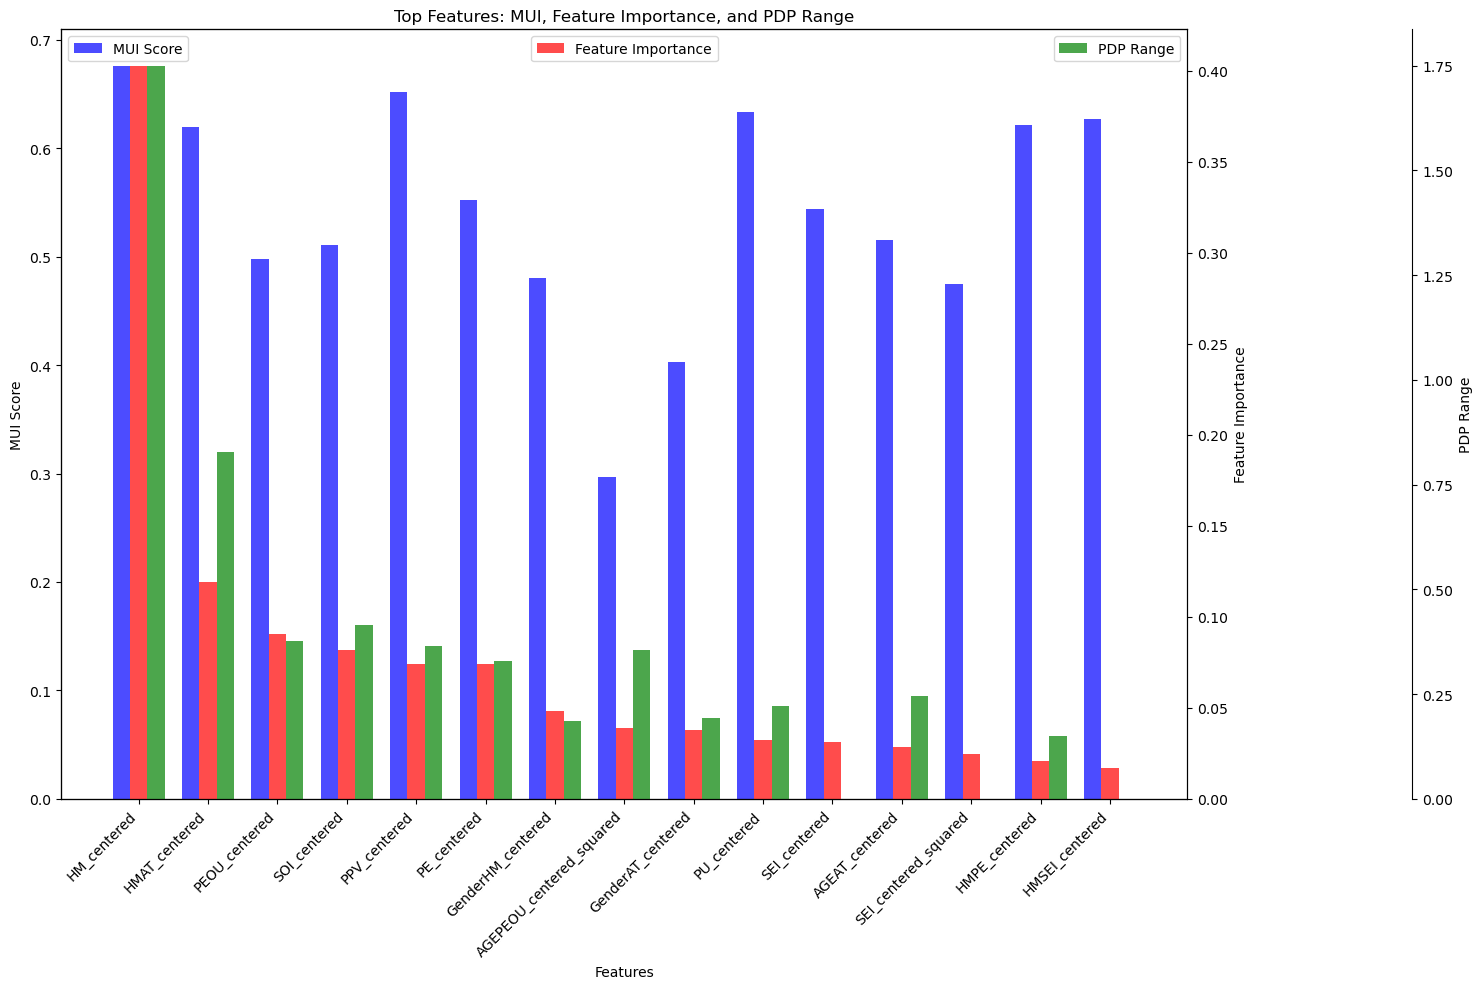

Combined plot of MUI, Feature Importance, and PDP Range has been saved.
Combined top 15 features: ['HMAT_centered_squared', 'HMPU_centered', 'HMPU_centered_squared', 'HM_centered', 'HMSEI_centered_squared', 'HMPEOU_centered', 'PPV_centered', 'HM_centered_squared', 'PU_centered_squared', 'PU_centered', 'HMSEI_centered', 'HMPE_centered', 'HMAT_centered', 'HMPEOU_centered_squared', 'AGEHM_centered']
Successfully saved top 15 features to C:\Users\cemcd\Documents\AR VTO Dissertation\AR VTO Dissertation Oct 6\AR VTO Latest Version Oct16 using PCA as Input\lasso_All_top_15_combined_features.json
Verified: Loaded 15 features from the file.
First few features: ['HMAT_centered_squared', 'HMPU_centered', 'HMPU_centered_squared', 'HM_centered', 'HMSEI_centered_squared']

Top 15 combined feature names saved to: lasso_All_top_15_combined_features.json
Updated feature importance DataFrame (including MUI scores) saved to: lasso_All_important_features.csv
End of Script 3


In [26]:
print(f" 3. RF Model using PCA features")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, RandomizedSearchCV
from sklearn.inspection import partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from scipy.stats import uniform, randint
import json


# Open and read the JSON file
try:
    with open('PCA_selected_features.json', 'r') as json_file:
        feature_data = json.load(json_file)

    # Extract the list of selected features
    pca_selected_features = feature_data['PCA_selected_features']

    print("Type of pca_selected_features:", type(pca_selected_features))
    print("First few items in pca_selected_features:")
    for item in pca_selected_features[:5]:
        print(f"  {item} (type: {type(item)})")

    # If pca_selected_features is a list of strings, use this:
    selected_features = list(dict.fromkeys(pca_selected_features))

    print(f"\nSuccessfully loaded {len(feature_vars)} unique PCA selected features.")
    print("\nFirst 5 features:")
    for feature in selected_features[:5]:
        print(f"- {feature}")

    print(f"\nLast 5 features:")
    for feature in selected_features[-5:]:
        print(f"- {feature}")

    print(f"\nNumber of unique features: {len(feature_vars)}")

except FileNotFoundError:
    print("Error: The file 'PCA_selected_features.json' was not found.")
except json.JSONDecodeError:
    print("Error: There was a problem decoding the JSON file.")
except KeyError:
    print("Error: The key 'PCA_selected_features' was not found in the JSON file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    
# Select the first 30 features from feature_vars
#feature_vars = selected_features[:30]

feature_vars = selected_features

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

# AGE and Gender are both numerical categorical features, check to see if AGE_num_1, 2,3 and Gender_num_1 are in the PCA list but not in df_survey_cleaned
missing_columns = [col for col in feature_vars if col not in df_survey_cleaned.columns]
print("Missing columns:", missing_columns)

# First, check if 'AGE' and 'Gender' columns exist
if 'AGE_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    # Create age dummy variables
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            # Binary variable
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            # Categorical variable
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

# Convert boolean columns to int
bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

# Ensure all features are numeric
feature_vars = [col for col in feature_vars if df_survey_cleaned[col].dtype in ['int64', 'float64']]

print("Updated feature variables:", feature_vars)
print(df_survey_cleaned[feature_vars].dtypes)



X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Separate numeric and categorical features
numeric_features = [col for col in feature_vars if col not in ['AGE_num', 'Gender_num']]
categorical_features = ['AGE_num', 'Gender_num']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
       #, ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# Perform cross-validation with MUI and feature importance
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []
feature_importance = {feature: [] for feature in feature_vars}
mui_scores = {feature: [] for feature in feature_vars}

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # Preprocess the data
    preprocessor.fit(X_fold_train)
    X_fold_train_preprocessed = preprocessor.transform(X_fold_train)
    X_fold_val_preprocessed = preprocessor.transform(X_fold_val)
    
    # Calculate MUI scores
    mui_fold_scores = mutual_info_regression(X_fold_train_preprocessed, y_fold_train)
    for i, feature in enumerate(feature_vars):
        mui_scores[feature].append(mui_fold_scores[i])
    
    # Train the model
    model = Lasso(alpha=.01, random_state=42)
    model.fit(X_fold_train_preprocessed, y_fold_train)
    
    # Calculate feature importance
    for i, feature in enumerate(feature_vars):
        feature_importance[feature].append(abs(model.coef_[i]))
    
    # Make predictions and calculate scores
    y_pred = model.predict(X_fold_val_preprocessed)
    mse = mean_squared_error(y_fold_val, y_pred)
    r2 = r2_score(y_fold_val, y_pred)
    
    cv_scores.append({'MSE': mse, 'R2': r2})

# Calculate average scores
avg_mse = np.mean([score['MSE'] for score in cv_scores])
avg_r2 = np.mean([score['R2'] for score in cv_scores])

print(f"Average MSE: {avg_mse}")
print(f"Average R2: {avg_r2}")

# Calculate average feature importance and MUI scores
avg_feature_importance = {feature: np.mean(scores) for feature, scores in feature_importance.items()}
avg_mui_scores = {feature: np.mean(scores) for feature, scores in mui_scores.items()}

# Perform cross-validation on the best model
cv_results = cross_validate(model, X_train, y_train, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)

# Calculate mean and std of the scores
train_mse = -cv_results['train_neg_mean_squared_error']
test_mse = -cv_results['test_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_r2 = cv_results['test_r2']

print("Lasso Regressor (Best Model) Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['Lasso 3 (PCA)'],
    'run_type': ['3rd Run - Random Grid Search'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]
})
#save model metrics to csv file
model_metrics.to_csv('lasso_3_model_metrics.csv')

# Sort features by importance
sorted_features = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)
top_features = [feature for feature, _ in sorted_features[:15]]

# Fit the final model on the entire training set
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=.01, random_state=42))
])
pipeline.fit(X_train, y_train)

# Calculate PDP values for top features
pdp_values = {}
pdp_ranges = {}

for feature in top_features:
    pdp = partial_dependence(pipeline, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp["values"][0], pdp["average"][0])
    pdp_ranges[feature] = np.ptp(pdp["average"][0])  # Range of PDP values

# Create results dictionary
results = {
    'top_features': top_features,
    'feature_importance': {feature: avg_feature_importance[feature] for feature in top_features},
    'mui_scores': {feature: avg_mui_scores[feature] for feature in top_features},
    'pdp_values': {feature: pdp_values[feature][1].tolist() for feature in top_features},
    'pdp_feature_values': {feature: pdp_values[feature][0].tolist() for feature in top_features}
}

# Save results to JSON file
with open('feature_analysis_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nFeature analysis results saved to: feature_analysis_results.json")

# Create lasso_important_features dataframe
lasso_important_features = pd.DataFrame([
    {'feature': feature, 'importance': avg_feature_importance[feature], 
     'mui_score': avg_mui_scores[feature], 'pdp_range': pdp_ranges.get(feature, np.nan)}
    for feature in feature_vars
])
lasso_important_features = lasso_important_features.sort_values('importance', ascending=False)
lasso_important_features.insert(0, 'model_name', 'Lasso')

print("\nFeature Importance, MUI Scores, and PDP Ranges:")
print(lasso_important_features)

# Save dataframe to CSV file
lasso_important_features.to_csv('lasso_important_features.csv', index=False)
print("\nFeature importance dataframe saved to: lasso_important_features.csv")

# Evaluate the model on the training set
y_train_pred = pipeline.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("\nTraining set evaluation:")
print(f"Training set MSE: {train_mse:.4f}")
print(f"Training set R2: {train_r2:.4f}")

# Evaluate the model on the test set
y_test_pred = pipeline.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print("\nTest set evaluation:")
print(f"Test set MSE: {test_mse:.4f}")
print(f"Test set R2: {test_r2:.4f}")

# Calculate and print the difference between training and test performance
mse_difference = train_mse - test_mse
r2_difference = train_r2 - test_r2
print("\nDifference between training and test performance:")
print(f"MSE difference (train - test): {mse_difference:.4f}")
print(f"R2 difference (train - test): {r2_difference:.4f}")


# After calculating PDP values and ranges, add this code:

# Calculate MUI scores for the entire training set
X_train_preprocessed = preprocessor.fit_transform(X_train)
mui_scores = mutual_info_regression(X_train_preprocessed, y_train)
mui_dict = dict(zip(feature_vars, mui_scores))

# Create a combined bar plot for MUI, Feature Importance, and PDP Range
plt.figure(figsize=(15, 10))
x = range(len(top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the right spine of ax3 by 60 points
ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [mui_dict[f] for f in top_features], width, label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [avg_feature_importance[f] for f in top_features], width, label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges[f] for f in top_features], width, label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('Top Features: MUI, Feature Importance, and PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(top_features, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

fig.tight_layout()
plt.show()
plt.savefig('lasso_top_features_mui_importance_pdp.png', dpi=300, bbox_inches='tight')
plt.close()

print("Combined plot of MUI, Feature Importance, and PDP Range has been saved.")

# Update the results dictionary to include MUI scores
results['mui_scores'] = {feature: mui_dict[feature] for feature in top_features}

# Get top 15 features based on MUI scores
mui_top_15 = sorted(mui_dict.items(), key=lambda x: x[1], reverse=True)[:15]
mui_top_15_names = [feature for feature, _ in mui_top_15]

# Get top 15 features based on PDP ranges
pdp_top_15 = sorted(pdp_ranges.items(), key=lambda x: x[1], reverse=True)[:15]
pdp_top_15_names = [feature for feature, _ in pdp_top_15]

# Get top 15 features based on feature importance
importance_top_15 = sorted(avg_feature_importance.items(), key=lambda x: x[1], reverse=True)[:15]
importance_top_15_names = [feature for feature, _ in importance_top_15]

# Combine all top features and remove duplicates while preserving order
all_top_features = mui_top_15_names + pdp_top_15_names + importance_top_15_names
top_15_feature_names = list(dict.fromkeys(all_top_features))[:15]

print(f"Combined top 15 features: {top_15_feature_names}")

import os
import json

# Define the file name
file_name = 'lasso_All_top_15_combined_features.json'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
results_file_path = os.path.join(current_dir, file_name)

# Save the top 15 important features to a JSON file
try:
    with open(results_file_path, 'w') as f:
        json.dump(top_15_feature_names, f, indent=4)
    print(f"Successfully saved top 15 features to {results_file_path}")

    # Verify the saved data
    with open(results_file_path, 'r') as f:
        loaded_features = json.load(f)
    print(f"Verified: Loaded {len(loaded_features)} features from the file.")
    print("First few features:", loaded_features[:5])
except Exception as e:
    print(f"An error occurred: {str(e)}")

print("\nTop 15 combined feature names saved to: lasso_All_top_15_combined_features.json")

# Update the lasso_important_features DataFrame to include MUI scores
lasso_important_features['mui_score'] = lasso_important_features['feature'].map(mui_dict)

# Save DataFrame to CSV
lasso_important_features.to_csv('lasso_important_features.csv', index=False)
print("Updated feature importance DataFrame (including MUI scores) saved to: lasso_All_important_features.csv")

print('End of Script 3')

### 4. Lasso Model Using PCA as Feature List - Grid Search 

4. Grid Search 4 Model using PCA Feature List.

Successfully loaded 64 unique PCA selected features.
Number of features selected: 64
Selected features:
['AGEGender_centered_squared', 'AGEGender_centered', 'GenderPEOU_centered_squared', 'AGEPEOU_centered_squared', 'GenderPEOU_centered', 'AGESOI_centered_squared', 'AGESEI_centered_squared', 'PEOU_centered_squared', 'AGEPEOU_centered', 'PEOU_centered', 'AGEPPV_centered_squared', 'GenderAT_centered', 'GenderSEI_centered', 'AGEHM_centered_squared', 'GenderPU_centered', 'GenderHM_centered', 'AGEPU_centered_squared', 'GenderAT_centered_squared', 'GenderPE_centered', 'GenderPE_centered_squared', 'GenderSEI_centered_squared', 'GenderPPV_centered', 'GenderSOI_centered', 'GenderSOI_centered_squared', 'GenderPPV_centered_squared', 'PE_centered', 'GenderHM_centered_squared', 'AGEPE_centered', 'AGESOI_centered', 'SOI_centered', 'GenderPU_centered_squared', 'AGEPPV_centered', 'AGEPU_centered', 'PU_centered', 'AGEHM_centered', 'SOI_centered_squared', 

<Figure size 1500x1000 with 0 Axes>

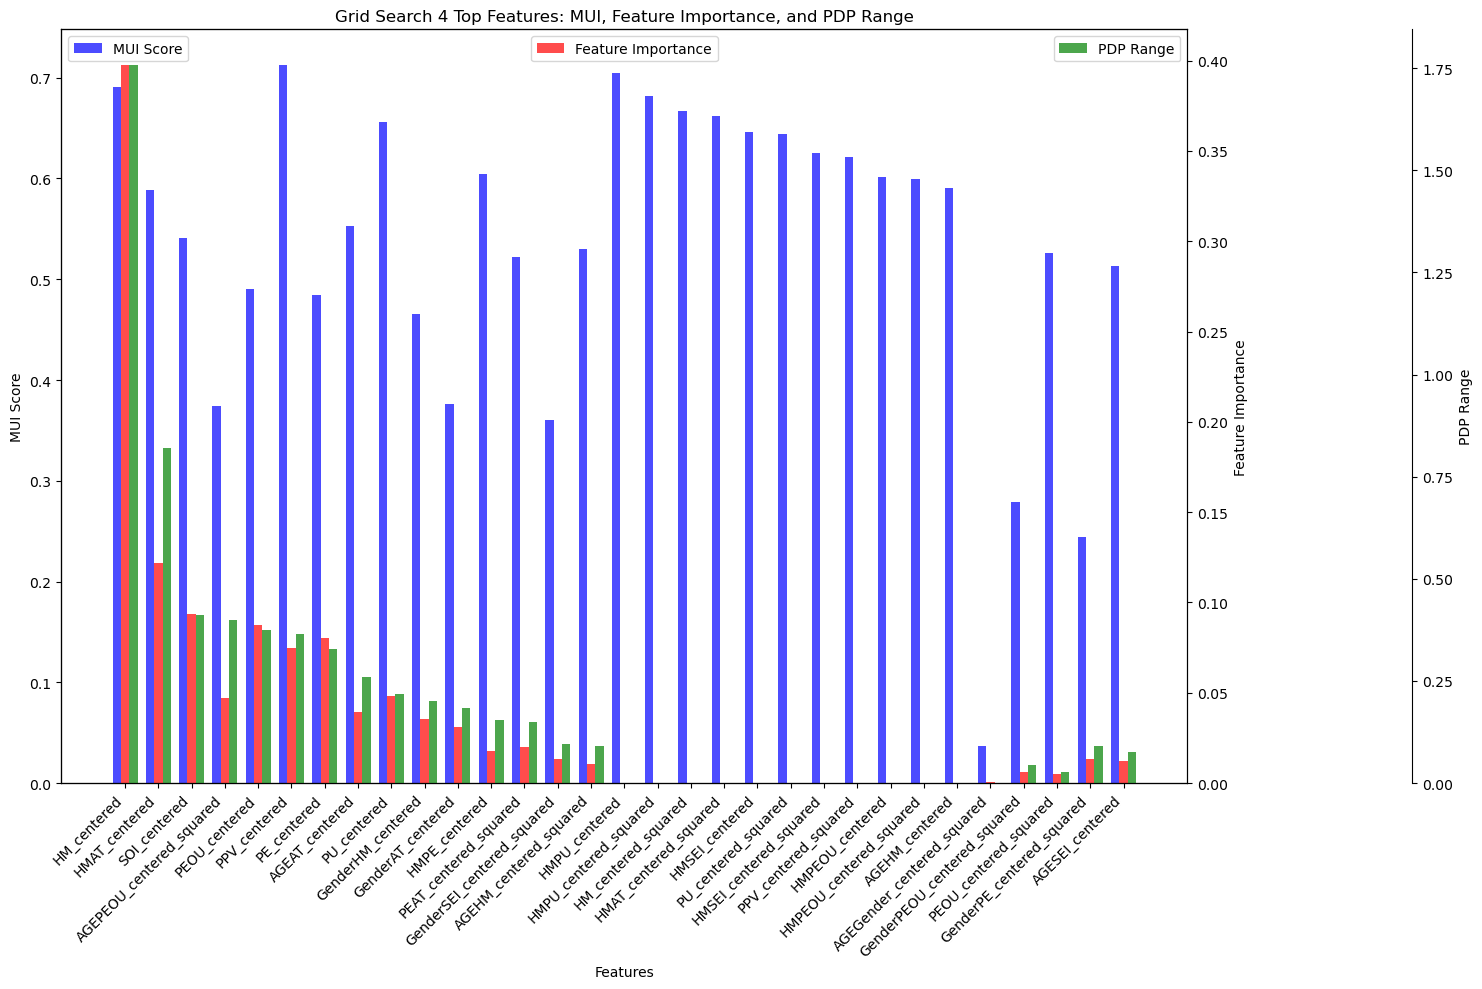


Top features importance plot saved as: grid_search_4_top_features_mui_importance_pdp.png

Combined top features and best parameters saved to: grid_search_4_output.json
Grid Search 4 PDP plots and summary have been saved (sorted by importance).

Grid Search 4 Partial Dependence Values for Features (Sorted by Importance):

Feature: HM_centered
PDP values:
 -2.87: 2.5444
 -2.54: 2.6909
 -2.20: 2.8373
 -1.87: 2.9838
 -1.54: 3.1302
 -1.20: 3.2767
 -0.87: 3.4231
 -0.54: 3.5696
 -0.20: 3.7160
 0.13: 3.8625
 0.46: 4.0089
 0.80: 4.1554
 1.13: 4.3018

Feature: HMAT_centered
PDP values:
 -1.20: 3.9668
 -1.01: 3.9509
 -0.72: 3.9253
 -0.63: 3.9166
 -0.57: 3.9113
 -0.45: 3.9009
 -0.43: 3.8998
 -0.40: 3.8966
 -0.31: 3.8890
 -0.23: 3.8820
 -0.20: 3.8792
 -0.19: 3.8781
 -0.17: 3.8764
 -0.14: 3.8743
 -0.13: 3.8732
 -0.11: 3.8711
 -0.10: 3.8705
 -0.08: 3.8683
 -0.07: 3.8673
 -0.03: 3.8645
 -0.02: 3.8634
 0.02: 3.8596
 0.03: 3.8586
 0.07: 3.8558
 0.08: 3.8547
 0.09: 3.8537
 0.10: 3.8526
 0.11: 3.8520
 0.

In [27]:
print(f"4. Grid Search 4 Model using PCA Feature List.")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, train_test_split, KFold, GridSearchCV
from sklearn.inspection import partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso
import json

# Load PCA selected features
try:
    with open('PCA_selected_features.json', 'r') as json_file:
        feature_data = json.load(json_file)
    selected_features = list(dict.fromkeys(feature_data['PCA_selected_features']))
    print(f"\nSuccessfully loaded {len(selected_features)} unique PCA selected features.")
except Exception as e:
    print(f"An error occurred while loading PCA features: {e}")
    selected_features = []

feature_vars = selected_features

print(f"Number of features selected: {len(feature_vars)}")
print("Selected features:")
print(feature_vars)

# Data preprocessing (assuming df_survey_cleaned is already defined)
missing_columns = [col for col in feature_vars if col not in df_survey_cleaned.columns]
print("Missing columns:", missing_columns)

# Create dummy variables for AGE and Gender
if 'AGE_num' in df_survey_cleaned.columns:
    df_survey_cleaned['AGE_num_1'] = (df_survey_cleaned['AGE_num'] == 1).astype(int)
    df_survey_cleaned['AGE_num_2'] = (df_survey_cleaned['AGE_num'] == 2).astype(int)
    df_survey_cleaned['AGE_num_3'] = (df_survey_cleaned['AGE_num'] == 3).astype(int)

if 'Gender_num' in df_survey_cleaned.columns:
    df_survey_cleaned['Gender_num_1'] = (df_survey_cleaned['Gender_num'] == 1).astype(int)

# Handle categorical variables
for col in feature_vars:
    if df_survey_cleaned[col].dtype == 'object':
        if df_survey_cleaned[col].nunique() == 2:
            df_survey_cleaned[col] = pd.get_dummies(df_survey_cleaned[col], drop_first=True)
        else:
            dummies = pd.get_dummies(df_survey_cleaned[col], prefix=col, drop_first=True)
            df_survey_cleaned = pd.concat([df_survey_cleaned, dummies], axis=1)
            feature_vars.extend(dummies.columns)
            feature_vars.remove(col)

# Convert boolean columns to int
bool_columns = df_survey_cleaned[feature_vars].select_dtypes(include=['bool']).columns
df_survey_cleaned[bool_columns] = df_survey_cleaned[bool_columns].astype(int)

X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), feature_vars)
    ])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(random_state=42))
])

# Define the parameter grid for grid search
param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10],
    'model__max_iter': [1000, 3000, 5000],
    'model__tol': [1e-4, 1e-5],
    'model__fit_intercept': [True, False],
    'model__positive': [True, False],
    'model__selection': ['cyclic', 'random']
}

# Perform grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Perform cross-validation on the best model
cv_results = cross_validate(best_model, X_train, y_train, cv=5,
                            scoring=('neg_mean_squared_error', 'r2'),
                            return_train_score=True)

# Calculate mean and std of the scores
train_mse = -cv_results['train_neg_mean_squared_error']
test_mse = -cv_results['test_neg_mean_squared_error']
train_r2 = cv_results['train_r2']
test_r2 = cv_results['test_r2']

print("Grid Search 4 Results (5-fold Cross-Validation):")
print("--------------------------------")
print(f"Training MSE: {train_mse.mean():.4f} (+/- {train_mse.std() * 2:.4f})")
print(f"Training R^2: {train_r2.mean():.4f} (+/- {train_r2.std() * 2:.4f})")
print(f"Testing MSE: {test_mse.mean():.4f} (+/- {test_mse.std() * 2:.4f})")
print(f"Testing R^2: {test_r2.mean():.4f} (+/- {test_r2.std() * 2:.4f})")

# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['LASSO 4 (PCA)'],
    'run_type': ['Grid Search'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]
})

# Save model_metrics to csv file
model_metrics.to_csv('grid_search_4_model_metrics.csv')

# Calculate PDP values for all features
pdp_values = {}
pdp_ranges = {}

for feature in feature_vars:
    pdp = partial_dependence(best_model, X_train, [feature], kind="average")
    pdp_values[feature] = (pdp["values"][0], pdp["average"][0])
    pdp_ranges[feature] = np.ptp(pdp["average"][0])  # Range of PDP values

# Sort features by PDP range
sorted_features = sorted(pdp_ranges.items(), key=lambda x: x[1], reverse=True)

# Create grid_search_4_important_PDP_features dataframe
lasso_4_important_PDP_features = pd.DataFrame(sorted_features, columns=['feature', 'pdp_range'])
lasso_4_important_PDP_features.insert(0, 'model_name', 'Grid Search 4')

print("\nGrid Search 4 PDP Importance (Range) for Features:")
print(grid_search_4_important_PDP_features)

# Calculate Mutual Information scores
mui_scores = mutual_info_regression(X_train, y_train)
mui_feature_importance = pd.DataFrame({'feature': X_train.columns, 'mui_score': mui_scores})
mui_feature_importance = mui_feature_importance.sort_values('mui_score', ascending=False)

# Get top 15 features from each category
top_pdp = grid_search_4_important_PDP_features['feature'].head(15).tolist()
top_mui = mui_feature_importance['feature'].head(15).tolist()
top_model = [name for name, coef in zip(X_train.columns, best_model.named_steps['model'].coef_) if coef != 0][:15]

# Combine and deduplicate
combined_top_features = list(dict.fromkeys(top_pdp + top_mui + top_model))

# Create dictionaries for quick lookup
mui_dict = dict(zip(mui_feature_importance['feature'], mui_feature_importance['mui_score']))
avg_feature_importance = dict(zip(X_train.columns, abs(best_model.named_steps['model'].coef_)))

# Create a combined bar plot for MUI, Feature Importance, and PDP Range
plt.figure(figsize=(15, 10))
x = range(len(combined_top_features))
width = 0.25

fig, ax1 = plt.subplots(figsize=(15, 10))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Offset the right spine of ax3 by 60 points
ax3.spines['right'].set_position(('axes', 1.2))

rects1 = ax1.bar([i - width for i in x], [mui_dict.get(f, 0) for f in combined_top_features], width, label='MUI Score', color='b', alpha=0.7)
rects2 = ax2.bar(x, [avg_feature_importance.get(f, 0) for f in combined_top_features], width, label='Feature Importance', color='r', alpha=0.7)
rects3 = ax3.bar([i + width for i in x], [pdp_ranges.get(f, 0) for f in combined_top_features], width, label='PDP Range', color='g', alpha=0.7)

ax1.set_xlabel('Features')
ax1.set_ylabel('MUI Score')
ax2.set_ylabel('Feature Importance')
ax3.set_ylabel('PDP Range')
ax1.set_title('Grid Search 4 Top Features: MUI, Feature Importance, and PDP Range')
ax1.set_xticks(x)
ax1.set_xticklabels(combined_top_features, rotation=45, ha='right')

ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

fig.tight_layout()
plt.show()
plt.savefig('grid_search_4_top_features_mui_importance_pdp.png', dpi=300, bbox_inches='tight')
plt.close()

print("\nTop features importance plot saved as: grid_search_4_top_features_mui_importance_pdp.png")

# Save combined top features and best parameters to JSON
output_data = {
    'combined_top_features': combined_top_features,
    'best_parameters': grid_search.best_params_
}

with open('grid_search_4_output.json', 'w') as f:
    json.dump(output_data, f)

print("\nCombined top features and best parameters saved to: grid_search_4_output.json")

print("Grid Search 4 PDP plots and summary have been saved (sorted by importance).")

# Print PDP values (sorted by importance)
print("\nGrid Search 4 Partial Dependence Values for Features (Sorted by Importance):")
for feature, _ in sorted_features:
    x, y = pdp_values[feature]
    print(f"\nFeature: {feature}")
    print("PDP values:")
    for val, pdp_val in zip(x, y):
        print(f" {val:.2f}: {pdp_val:.4f}")

# Save dataframes to CSV files
grid_search_4_important_PDP_features.to_csv('grid_search_4_important_PDP_features.csv', index=False)
model_metrics.to_csv('grid_search_4_model_metrics.csv', index=False)

print("\nDataframes saved to CSV files:")
print("grid_search_4_important_PDP_features.csv")
print("grid_search_4_model_metrics.csv")

# Calculate Mutual Information scores
mui_scores = mutual_info_regression(X_train, y_train)
mui_feature_importance = pd.DataFrame({'feature': X_train.columns, 'mui_score': mui_scores})
mui_feature_importance = mui_feature_importance.sort_values('mui_score', ascending=False)

# Get top 15 features from each category
top_pdp = grid_search_4_important_PDP_features['feature'].head(15).tolist()
top_mui = mui_feature_importance['feature'].head(15).tolist()
top_model = [name for name, coef in zip(X_train.columns, best_model.named_steps['model'].coef_) if coef != 0][:15]

# Calculate Mutual Information scores
mui_scores = mutual_info_regression(X_train, y_train)
mui_feature_importance = pd.DataFrame({'feature': X_train.columns, 'mui_score': mui_scores})
mui_feature_importance = mui_feature_importance.sort_values('mui_score', ascending=False)

# Get top 15 features from each category
top_pdp = lasso_4_important_PDP_features['feature'].head(15).tolist()
top_mui = mui_feature_importance['feature'].head(15).tolist()
top_model = [name for name, coef in zip(X_train.columns, best_model.named_steps['model'].coef_) if coef != 0][:15]

# Combine and deduplicate
combined_top_features = list(dict.fromkeys(top_pdp + top_mui + top_model))

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Feature': combined_top_features,
    'PDP Range': [pdp_ranges.get(feature, 0) for feature in combined_top_features],
    'MUI Score': [mui_feature_importance[mui_feature_importance['feature'] == feature]['mui_score'].values[0] if feature in mui_feature_importance['feature'].values else 0 for feature in combined_top_features],
    'Model Coefficient': [abs(best_model.named_steps['model'].coef_[list(X_train.columns).index(feature)]) if feature in X_train.columns else 0 for feature in combined_top_features]
})

# Sort by the sum of all importance measures
plot_data['Total Importance'] = plot_data['PDP Range'] + plot_data['MUI Score'] + plot_data['Model Coefficient']
plot_data = plot_data.sort_values('Total Importance', ascending=False).head(15)

# Create the plot
plt.figure(figsize=(12, 8))
bar_width = 0.25
index = np.arange(len(plot_data))

plt.bar(index, plot_data['PDP Range'], bar_width, label='PDP Range', alpha=0.8)
plt.bar(index + bar_width, plot_data['MUI Score'], bar_width, label='MUI Score', alpha=0.8)
plt.bar(index + 2*bar_width, plot_data['Model Coefficient'], bar_width, label='|Model Coefficient|', alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Lasso Top 4 15 Features by Three Importance Measures')
plt.xticks(index + bar_width, plot_data['Feature'], rotation=90)
plt.legend()
plt.tight_layout()
plt.savefig('lasso_4_top_15_features_importance.png', dpi=300, bbox_inches='tight')
plt.close()

print("\nTop 15 features importance plot saved as: lasso_4_top_15_features_importance.png")

# Combine and deduplicate
combined_top_features = list(dict.fromkeys(top_pdp + top_mui + top_model))
top_15_features = combined_top_features[:15]

# Save combined top features to JSON
with open('lasso_4_combined_top_features.json', 'w') as f:
    json.dump(top_15_features, f)

print("\nCombined top features saved to: lasso_4_combined_top_features.json")

# Save best parameters to JSON
with open('lasso_4_best_parameters.json', 'w') as f:
    json.dump(grid_search.best_params_, f)

print("Best 4 parameters saved to: lasso_4_best_parameters.json")

with open('grid_search_4_output.json', 'w') as f:
    json.dump(output_data, f)

print("\nLasso 4 Combined top features and best parameters saved to: grid_search_4_output.json")

# Model evaluation
y_train_pred = best_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

y_test_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nModel Performance:")
print("------------------")
print(f"Training set MSE: {train_mse:.4f}")
print(f"Training set R²: {train_r2:.4f}")
print(f"Test set MSE: {test_mse:.4f}")
print(f"Test set R²: {test_r2:.4f}")

mse_difference = train_mse - test_mse
r2_difference = train_r2 - test_r2
print("\nDifference between training and test performance:")
print(f"MSE difference (train - test): {mse_difference:.4f}")
print(f"R² difference (train - test): {r2_difference:.4f}")

print("\nBest hyperparameters:")
print(grid_search.best_params_)

print('End of Script 4')

## 5. LaSSO model using Most Important Features and Best Hyperparameters 

Best parameters loaded successfully:
{
  "model__alpha": 0.01,
  "model__fit_intercept": true,
  "model__max_iter": 1000,
  "model__positive": false,
  "model__selection": "cyclic",
  "model__tol": 0.0001
}
Adjusted best parameters:
{
  "alpha": 0.01,
  "fit_intercept": true,
  "max_iter": 1000,
  "positive": false,
  "selection": "cyclic",
  "tol": 0.0001
}
Lasso features loaded successfully.
Number of features loaded: 15
Prefixes removed and AGE_num features consolidated successfully.
Updated features: ['HM_centered', 'HMAT_centered', 'SOI_centered', 'AGEPEOU_centered_squared', 'PEOU_centered', 'PPV_centered', 'PE_centered', 'AGEAT_centered', 'PU_centered', 'GenderHM_centered', 'GenderAT_centered', 'HMPE_centered', 'PEAT_centered_squared', 'GenderSEI_centered_squared', 'AGEHM_centered_squared']
Lasso 5 Model Performance:
------------------------
Training MSE: 0.1418
Training R²: 0.8173
Test MSE: 0.1049
Test R²: 0.8505

LASSO 5 Feature Importances:
                            feature 

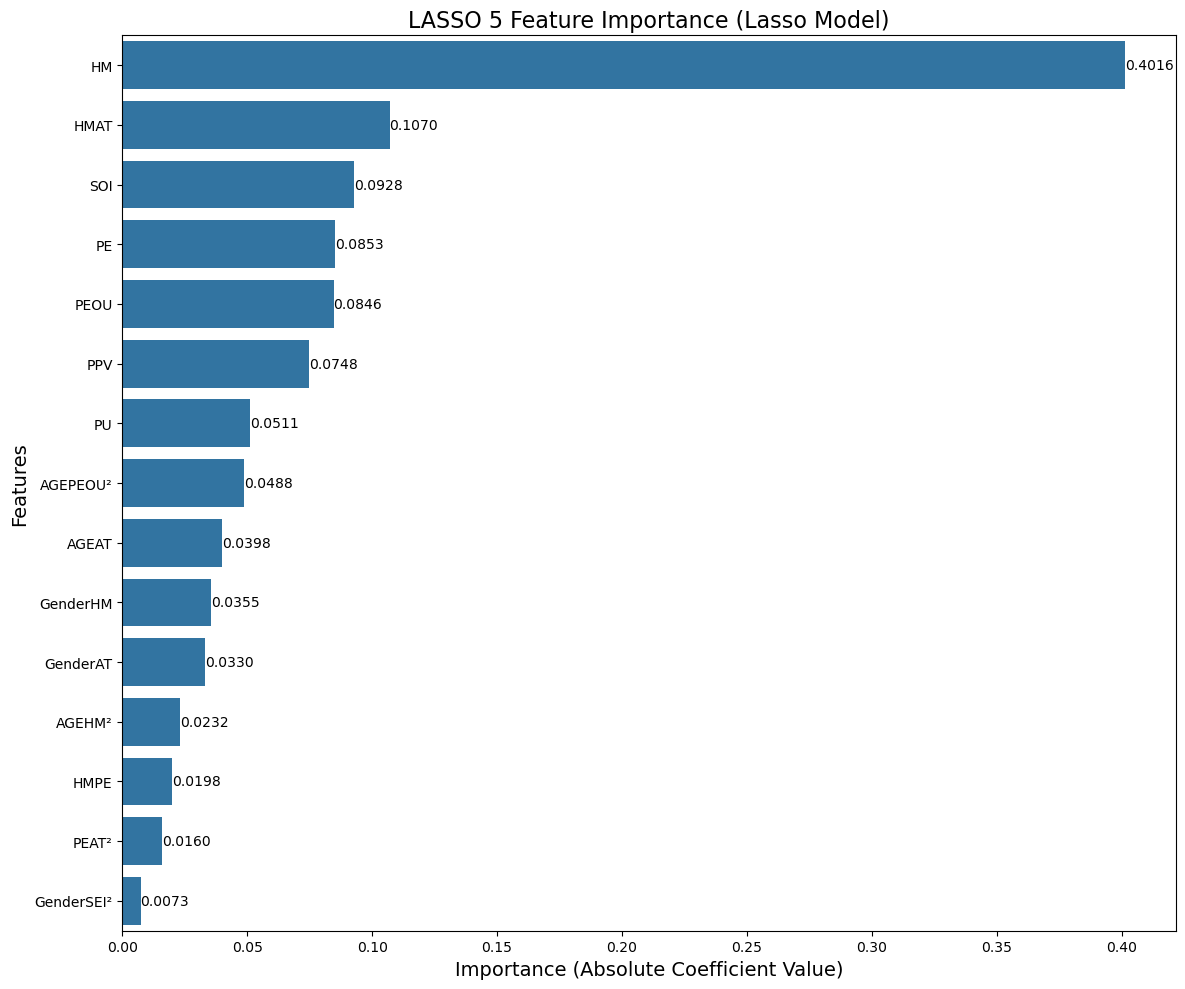

end of script 5


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import os
import json

# Define the filename
best_params_filename = 'lasso_4_best_parameters.json'

# Construct the file path relative to the current directory
best_params_file_path = os.path.join(os.getcwd(), best_params_filename)

try:
    with open(best_params_file_path, 'r') as f:
        best_params = json.load(f)
    print("Best parameters loaded successfully:")
    print(json.dumps(best_params, indent=2))
except Exception as e:
    print(f"An error occurred while reading the file: {str(e)}")
    best_params = {'model__weights': 'distance', 'model__n_neighbors': 13, 'model__metric': 'euclidean'}
    print("Using default parameters:")
    print(json.dumps(best_params, indent=2))

# Remove the 'model__' prefix from the parameters
best_params = {k.replace('model__', ''): v for k, v in best_params.items()}

print("Adjusted best parameters:")
print(json.dumps(best_params, indent=2))

import os
import json

# Define the filename
Lasso_features_filename = 'lasso_4_combined_top_features.json'

# Construct the file path relative to the current directory
Lasso_features_file = os.path.join(os.getcwd(), Lasso_features_filename)

try:
    with open(Lasso_features_file, 'r') as f:
        features_to_keep = json.load(f)
    print("Lasso features loaded successfully.")
    print(f"Number of features loaded: {len(features_to_keep)}")

    # Remove 'num__' and 'cat__' prefixes
    features_to_keep = [feature.replace('num__', '').replace('cat__', '') for feature in features_to_keep]

    # Replace 'AGE_num_X' with 'AGE_num'
    features_to_keep = ['AGE_num' if feature.startswith('AGE_num_') else feature for feature in features_to_keep]

    print("Prefixes removed and AGE_num features consolidated successfully.")
    print(f"Updated features: {features_to_keep}")

    # Check if all features exist in the DataFrame
    missing_features = [feature for feature in features_to_keep if feature not in df_survey_cleaned.columns]
    if missing_features:
        print(f"Warning: The following features are not in the DataFrame: {missing_features}")
        features_to_keep = [feature for feature in features_to_keep if feature in df_survey_cleaned.columns]
        print(f"Proceeding with the following features: {features_to_keep}")

except Exception as e:
    print(f"An error occurred while reading the file: {str(e)}")
    features_to_keep = []

feature_vars = features_to_keep

# Update X to use only available features
X = df_survey_cleaned[feature_vars]
y = df_survey_cleaned['BI']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate numeric and categorical features
numeric_features = [col for col in features_to_keep if col != 'AGE_num']
categorical_features = ['AGE_num']

# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
        #,('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])


# Create a pipeline with the preprocessor and Lasso model
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(**best_params, random_state=42))
])

# Fit the model
lasso_pipeline.fit(X_train, y_train)

# Make predictions
y_train_pred = lasso_pipeline.predict(X_train)
y_test_pred = lasso_pipeline.predict(X_test)

# Calculate performance metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print("Lasso 5 Model Performance:")
print("------------------------")
print(f"Training MSE: {train_mse:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test R²: {test_r2:.4f}")


# Create model_metrics dataframe
model_metrics = pd.DataFrame({
    'model_name': ['Lasso 5 (Final Run)'],
    'run_type': ['Final Run'],
    'train_mse_mean': [train_mse.mean()],
    'train_mse_std': [train_mse.std()],
    'train_r2_mean': [train_r2.mean()],
    'train_r2_std': [train_r2.std()],
    'test_mse_mean': [test_mse.mean()],
    'test_mse_std': [test_mse.std()],
    'test_r2_mean': [test_r2.mean()],
    'test_r2_std': [test_r2.std()]
})

#save model_metrics to csv file
model_metrics.to_csv('LASSO_5_model_metrics.csv', index=False)
# Get feature names after preprocessing
feature_names = (lasso_pipeline.named_steps['preprocessor']
                 .get_feature_names_out(feature_vars))

# Create feature importances DataFrame
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': abs(lasso_pipeline.named_steps['model'].coef_)
})
 
# Get feature names after preprocessing
feature_names = (lasso_pipeline.named_steps['preprocessor']
                 .get_feature_names_out(feature_vars))

# Create feature importances DataFrame
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': abs(lasso_pipeline.named_steps['model'].coef_)
})
lasso_5_feature_importances = feature_importances.sort_values('importance', ascending=False)

print("\nLASSO 5 Feature Importances:")
print(feature_importances)
 
import matplotlib.pyplot as plt
import seaborn as sns

# Remove the 'num__' prefix from the feature names
lasso_5_feature_importances['feature'] = lasso_5_feature_importances['feature'].str.replace('num__', '')

# Remove '_centered' and '_squared' suffixes for cleaner labels
lasso_5_feature_importances['feature'] = lasso_5_feature_importances['feature'].str.replace('_centered', '')
lasso_5_feature_importances['feature'] = lasso_5_feature_importances['feature'].str.replace('_squared', '²')

# Sort the features by importance in descending order
lasso_5_feature_importances_sorted = lasso_5_feature_importances.sort_values('importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 10))
sns.barplot(data=lasso_5_feature_importances_sorted, x='importance', y='feature')
plt.title('LASSO 5 Feature Importance (Lasso Model)', fontsize=16)
plt.xlabel('Importance (Absolute Coefficient Value)', fontsize=14)
plt.ylabel('Features', fontsize=14)

# Add value labels on top of each bar
for i, v in enumerate(lasso_5_feature_importances_sorted['importance']):
    plt.text(v, i, f'{v:.4f}', ha='left', va='center')

plt.tight_layout()
plt.savefig('lasso_5_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('end of script 5')


In [29]:
### Analyze final Model

## Capture all metrics into one file for anlysis

In [30]:
print(f"Capturing all model metrics")

Capturing all model metrics


### Read LASSO 1 Best Model Metrics

In [31]:
import os
import pandas as pd

# Define the file name
file_name = 'lasso_1_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    lasso_1_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    lasso_1_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    lasso_1_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    lasso_1_model_metrics = pd.DataFrame()  # Create an empty DataFrame-

Successfully read the file: lasso_1_model_metrics.csv


### Read LASSO 2A Best Model Metrics - Deafulat Parameters

In [32]:
import os
import pandas as pd

# Define the file name
file_name = 'lasso_2A_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    lasso_2A_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    lasso_2A_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    lasso_2A_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    lasso_2A_model_metrics = pd.DataFrame()  # Create an empty DataFrame-

Successfully read the file: lasso_2A_model_metrics.csv


In [33]:
### Read LASSO 2B Best Model Metrics

In [34]:
import os
import pandas as pd

# Define the file name
file_name = 'lasso_2_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    lasso_2_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    lasso_2_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    lasso_2_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    lasso_2_model_metrics = pd.DataFrame()  # Create an empty DataFrame-

Successfully read the file: lasso_2_model_metrics.csv


### Read LASSO 3 Best Model Metrics

In [35]:
import os
import pandas as pd

# Define the file name
file_name = 'lasso_3_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    lasso_3_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    lasso_3_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    lasso_3_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    lasso_3_model_metrics = pd.DataFrame()  # Create an empty DataFrame-

Successfully read the file: lasso_3_model_metrics.csv


### Read LASSO 4 Best Model Metrics

In [36]:
import os
import pandas as pd

# Define the file name
file_name = 'LASSO_4_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    LASSO_4_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    LASSO_4_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    LASSO_4_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    LASSO_4_model_metrics = pd.DataFrame()  # Create an empty DataFrame-

Successfully read the file: LASSO_4_model_metrics.csv


### Read LASSO 5 Best Model Metrics

In [37]:
import os
import pandas as pd

# Define the file name
file_name = 'LASSO_5_model_metrics.csv'

# Get the current working directory and create the full file path
current_dir = os.getcwd()
file_path = os.path.join(current_dir, file_name)

try:
    # Read the CSV file
    LASSO_5_model_metrics = pd.read_csv(file_path)
    print(f"Successfully read the file: {file_name}")

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory.")
    LASSO_5_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_name}' is empty.")
    LASSO_5_model_metrics = pd.DataFrame()  # Create an empty DataFrame
except Exception as e:
    print(f"An unexpected error occurred while reading the file: {str(e)}")
    LASSO_5_model_metrics = pd.DataFrame()  # Create an empty DataFrame-

Successfully read the file: LASSO_5_model_metrics.csv


In [38]:
LASSO_All_models_metrics_combined = pd.concat([lasso_1_model_metrics,lasso_2A_model_metrics,lasso_2_model_metrics,lasso_3_model_metrics,LASSO_4_model_metrics,LASSO_5_model_metrics],axis=0)

In [39]:
LASSO_All_models_metrics_combined['mse_diff'] = LASSO_All_models_metrics_combined['train_mse_mean'] - abs(LASSO_All_models_metrics_combined['test_mse_mean'])

In [40]:
LASSO_All_models_metrics_combined['r2_diff'] = LASSO_All_models_metrics_combined['train_r2_mean'] - abs(LASSO_All_models_metrics_combined['test_r2_mean'])

In [41]:
LASSO_All_models_metrics_combined[['model_name','run_type','train_r2_mean','test_r2_mean','r2_diff','train_mse_mean','test_mse_mean','mse_diff']]

,model_name,run_type,train_r2_mean,test_r2_mean,r2_diff,train_mse_mean,test_mse_mean,mse_diff
0,LASSO 1 (TAM ),Initial Run,0.808448,0.777976,0.030472,0.148390,0.167343,-0.018953
0,LASSO 2A (PCA),2 Run Default Paramaters,0.305039,0.265664,0.039375,0.538814,0.563881,-0.025066
0,LASSO 2A (PCA),2 Run Alpha = 0.01,0.829987,0.782602,0.047385,0.131663,0.163509,-0.031846
0,Lasso 3 (PCA),3rd Run - Random Grid Search,0.829987,0.782602,0.047385,0.131663,0.163509,-0.031846
0,Lasso (PCA),Run Grid Search,0.825073,0.777451,0.047621,0.135504,0.167390,-0.031886
0,Lasso 5 (Final Run),Final Run,0.817275,0.850490,-0.033214,0.141755,0.104924,0.036831


In [42]:
LASSO_All_models_metrics_combined.to_csv('LASSO_All_models_metrics_combined.csv', index=False)

In [43]:
print('End of Lasso Notebook')

End of Lasso Notebook
